# Enterprise Knowledge Mining System


## Imports & Configuration


In [1]:
import os
import re
import json
import zipfile
import time
import logging
import threading
import xml.etree.ElementTree as ET

import dotenv
import pymupdf as fitz
import chromadb
import spacy

from openai import OpenAI, RateLimitError
from langchain_text_splitters import RecursiveCharacterTextSplitter
from huggingface_hub import hf_hub_download, HfApi, list_repo_files, CommitOperationAdd
from huggingface_hub.utils import disable_progress_bars

import matplotlib.pyplot as plt

disable_progress_bars()

dotenv.load_dotenv()

OPENAI_KEY  = os.getenv("OPENAI_KEY")
HF_TOKEN    = os.getenv("HF_TOKEN")
HF_REPO_ID  = os.getenv("HF_REPO_ID")

client  = OpenAI(api_key=OPENAI_KEY)
hf_api  = HfApi(token=HF_TOKEN)

logging.basicConfig(filename="../pipeline.log", level=logging.INFO)
print("Imports OK")

c:\Users\816032048\Documents\GitHub\Enterprise-Knowledge-Mining-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
# Configuration

REPO_ROOT = os.path.abspath("..")

SEARCH_QUERY      = "all:computer"
MAX_RESULTS       = 1060       
ARXIV_PAGE_SIZE   = 100        
REQUEST_DELAY     = 3.0        

MIN_PAGE_LENGTH   = 100        
CHUNK_SIZE        = 800
CHUNK_OVERLAP     = 50
MAX_CHUNKS_PER_PAPER = 300

EMBEDDING_MODEL   = "text-embedding-3-small"
EMBED_BATCH_SIZE  = 200        
RAG_MODEL         = "gpt-4.1-mini"

CHROMA_PATH       = os.path.join(REPO_ROOT, "chroma_db")
COLLECTION_NAME   = "research_papers"
CHROMA_UPSERT_BATCH = 2000    

PDF_DIR           = os.path.join(REPO_ROOT, "pdfs")
CHECKPOINT_FILE   = os.path.join(REPO_ROOT, "files/checkpoint.json")
UPLOAD_BATCH_SIZE = 20

BASE_URL = "https://export.arxiv.org/api/query"
NS = {
    "atom":  "http://www.w3.org/2005/Atom",
    "arxiv": "http://arxiv.org/schemas/atom",
}

EXCLUDED_SECTIONS = {"References", "Acknowledgment", "Acknowledgements", "Acknowledgments"}

GROUND_TRUTH_PATH = os.path.join(REPO_ROOT, "files/ground_truth_dataset.json")

os.makedirs(PDF_DIR, exist_ok=True)
print("Config OK")

Config OK


In [3]:
# def upload_artifacts_to_hf():
#     # Upload chroma_db/ (zipped) to the HF dataset repo.
#     chroma_zip = "chroma_db.zip"
#     if not os.path.isdir(CHROMA_PATH):
#         print(f"  chroma_db directory not found at {CHROMA_PATH}.")
#         return

#     print("Zipping chroma_db/...")
#     with zipfile.ZipFile(chroma_zip, "w", zipfile.ZIP_DEFLATED) as zf:
#         for root, _, files in os.walk(CHROMA_PATH):
#             for fname in files:
#                 full = os.path.join(root, fname)
#                 zf.write(full, os.path.relpath(full, start=os.path.dirname(CHROMA_PATH)))
#     print(f"  Zipped — {os.path.getsize(chroma_zip) / 1e6:.1f} MB")

#     for attempt in range(5):
#         try:
#             hf_api.create_commit(
#                 repo_id=HF_REPO_ID,
#                 repo_type="dataset",
#                 operations=[CommitOperationAdd(
#                     path_in_repo=chroma_zip,
#                     path_or_fileobj=chroma_zip,
#                 )],
#                 commit_message="Upload chroma_db artifact",
#                 token=HF_TOKEN,
#             )
#             print("  chroma_db.zip uploaded to HF repo successfully.")
#             os.remove(chroma_zip)
#             return
#         except Exception as e:
#             wait = 2 ** attempt
#             print(f"  Upload failed ({e}), retrying in {wait}s...")
#             time.sleep(wait)
#     print("  Upload permanently failed.")


# def download_artifacts_from_hf():
#     # Download and extract chroma_db/ from the HF dataset repo.
#     chroma_zip = "chroma_db.zip"

#     print("Downloading chroma_db.zip from HF...")
#     hf_hub_download(
#         repo_id=HF_REPO_ID,
#         filename=chroma_zip,
#         repo_type="dataset",
#         token=HF_TOKEN,
#         local_dir=".",
#     )

#     print("Extracting...")
#     with zipfile.ZipFile(chroma_zip, "r") as zf:
#         zf.extractall(".")

#     os.remove(chroma_zip)
#     print("Done — chroma_db/ is ready.")

# # upload_artifacts_to_hf()
# download_artifacts_from_hf()

## Hugging Face helpers


In [4]:
# HuggingFace cache & upload queue

_hf_files_cache  = None
_hf_cache_lock   = threading.Lock()
_arxiv_semaphore = threading.Semaphore(4)
hf_upload_queue = []
hf_upload_lock = threading.Lock()
_counter_lock = threading.Lock()
_checkpoint_lock = threading.Lock()
_first_paper_done = threading.Event()


def get_hf_files():
    # Returns the set of filenames in the HF repo.
    global _hf_files_cache
    with _hf_cache_lock:
        if _hf_files_cache is None:
            try:
                _hf_files_cache = set(list_repo_files(
                    repo_id=HF_REPO_ID, repo_type="dataset", token=HF_TOKEN
                ))
                print(f"HF repo contains {len(_hf_files_cache)} files.")
            except Exception as e:
                print(f"HF fetch failed: {e}")
                _hf_files_cache = set()
        return _hf_files_cache


def pdf_exists_in_hf(filename):
    return filename in get_hf_files()


def upload_batch_to_hf(local_paths):
    # One commit for the entire batch regardless of size
    operations = [
        CommitOperationAdd(
            path_in_repo=os.path.basename(p),
            path_or_fileobj=p,
        )
        for p in local_paths
    ]
    for attempt in range(5):
        try:
            hf_api.create_commit(
                repo_id=HF_REPO_ID,
                repo_type="dataset",
                operations=operations,
                commit_message=f"Add {len(local_paths)} PDFs",
                token=HF_TOKEN,
            )
            with _hf_cache_lock:
                for p in local_paths:
                    _hf_files_cache.add(os.path.basename(p))
            return
        except Exception as e:
            wait = 2 ** attempt
            print(f"  HF batch upload failed ({e}), retrying in {wait}s...")
            time.sleep(wait)
    print(f"  HF batch upload permanently failed — skipping cache for this batch.")


def download_from_hf(filename, local_path):
    hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=filename,       
        repo_type="dataset",
        local_dir=os.path.dirname(local_path),
    )


def _upload_and_delete_batch(batch):
    print(f"Uploading batch of {len(batch)} files as single commit...")
    upload_batch_to_hf(batch)
    for p in batch:
        try:
            os.remove(p)
        except Exception as e:
            print(f"  Delete failed for {p}: {e}")


def queue_hf_upload(local_path):
    batch = None
    with hf_upload_lock:
        hf_upload_queue.append(local_path)
        if len(hf_upload_queue) >= UPLOAD_BATCH_SIZE:
            batch = hf_upload_queue[:]
            hf_upload_queue.clear()
    if batch:
        _upload_and_delete_batch(batch)


def flush_hf_uploads():
    with hf_upload_lock:
        if not hf_upload_queue:
            return
        batch = hf_upload_queue[:]
        hf_upload_queue.clear()
    _upload_and_delete_batch(batch)


print("HF helpers OK")

HF helpers OK


## Checkpoint


In [5]:
def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        return set(json.load(open(CHECKPOINT_FILE)))
    return set()


def save_checkpoint(ids):
    json.dump(list(ids), open(CHECKPOINT_FILE, "w"))


print("Checkpoint helpers OK")

Checkpoint helpers OK


## HTTP Helper

In [6]:
import urllib.request
import urllib.error

# HTTP helper with retry + rate-limit backoff

def make_request(url, delay=3.0, retries=3):
    for attempt in range(retries):
        try:
            req = urllib.request.Request(
                url,
                headers={"User-Agent": "arxiv-pipeline/1.0 (research script)"},
            )
            with urllib.request.urlopen(req) as resp:
                data = resp.read()
            time.sleep(delay)
            return data
        except urllib.error.HTTPError as e:
            if e.code == 429:
                wait = delay * (2 ** attempt)
                print(f"  429 rate-limit, waiting {wait:.0f}s...")
                time.sleep(wait)
            else:
                raise
    raise Exception("Max retries exceeded")

print("HTTP helper OK")

HTTP helper OK


## XML Parsing Helpers


In [7]:
# XML parsing helpers

def _get_text(entry, tag):
    return entry.findtext(tag, default="", namespaces=NS).strip()

def _extract_authors(entry):
    return [
        a.find("atom:name", NS).text.strip() 
        for a in entry.findall("atom:author", NS)
    ]


def _extract_categories(entry):
    return [
        c.attrib.get("term") 
        for c in entry.findall("atom:category", NS) 
        if c.attrib.get("term")
    ]


def _extract_pdf_link(entry):
    return next(
        (
            l.attrib.get("href")
            for l in entry.findall("atom:link", NS)
            if l.attrib.get("title") == "pdf"
            and l.attrib.get("type") == "application/pdf"
            and l.attrib.get("rel") == "related"
        ),
        None,
    )


def _extract_primary_category(entry):
    primary = entry.find("arxiv:primary_category", NS)
    return primary.attrib.get("term") if primary is not None else None


def _parse_entry(entry):
    return {
        "arxiv_id":        _get_text(entry, "atom:id").split("/")[-1],
        "title":           _get_text(entry, "atom:title"),
        "summary":         _get_text(entry, "atom:summary"),
        "published":       _get_text(entry, "atom:published"),
        "authors":         _extract_authors(entry),
        "primary_category":_extract_primary_category(entry),
        "categories":      _extract_categories(entry),
        "pdf_link":        _extract_pdf_link(entry),
    }


def _parse_response(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return [_parse_entry(e) for e in root.findall("atom:entry", NS)]

print("XML Parsing Helpers OK")

XML Parsing Helpers OK


## arXiv fetching

In [8]:
import urllib.parse

# Paginated fetcher

def fetch_papers(search_query=SEARCH_QUERY, max_results=MAX_RESULTS,
                 page_size=ARXIV_PAGE_SIZE, delay=REQUEST_DELAY):
    # Fetches up to max_results papers from arXiv in pages of page_size
    all_papers = []
    fetched    = 0

    while fetched < max_results:
        batch = min(page_size, max_results - fetched)
        params = urllib.parse.urlencode({
            "search_query": search_query,
            "start":        fetched,
            "max_results":  batch,
        })
        url = f"{BASE_URL}?{params}"
        print(f"  Fetching papers {fetched + 1}–{fetched + batch}...")
        xml_bytes = make_request(url, delay=delay)
        page = _parse_response(xml_bytes)
        if not page:
            print("  arXiv returned 0 entries — stopping early.")
            break
        all_papers.extend(page)
        fetched += len(page)

    print(f"Fetched {len(all_papers)} paper records.")
    return all_papers


print("Fetch helpers OK")

Fetch helpers OK


## PDF download & parsing


In [9]:
def sanitize_filename(name):
    name = re.sub(r'[\\/*?:"<>|]', "_", name)
    return name[:150]


def get_pdf(paper):
    # Download PDF from HF cache or arXiv, return local path.
    filename   = f"{sanitize_filename(paper['title'])}.pdf"
    local_path = os.path.join(PDF_DIR, filename)

    # 1. Already on disk
    if os.path.exists(local_path):
        return local_path

    # 2. HF cache hit
    if pdf_exists_in_hf(filename):
        try:
            download_from_hf(filename, local_path)
            return local_path
        except Exception as e:
            print(f"  HF download failed for {filename}: {e}")

    # 3. Download from arXiv
    if not paper.get("pdf_link"):
        raise ValueError(f"No PDF link for {paper['arxiv_id']}")

    with _arxiv_semaphore:
        data = make_request(paper["pdf_link"], delay=REQUEST_DELAY)
    with open(local_path, "wb") as f:
        f.write(data)

    queue_hf_upload(local_path)
    
    return local_path

In [10]:
_ROMAN_PREFIX   = re.compile(
    r'^(X{0,3}(?:IX|IV|VI{0,3}|I{1,3})|[A-Z])[\.\)]\s+\S', re.IGNORECASE
)
_NUMERIC_PREFIX = re.compile(r'^\d+(?:\.\d+)*\.?\s+[A-Z]')
_KNOWN_SECTIONS = re.compile(
    r'^(abstract|introduction|conclusions?|related\s+work|background|'
    r'methodology|methods?|results?|discussion|experiments?|evaluation|'
    r'overview|summary|appendix|acknowledgm\w*|references?|future\s+work|'
    r'limitations?|contributions?|preliminaries|notation|dataset[s]?|'
    r'problem\s+(statement|formulation|definition)|'
    r'experimental\s+(setup|results?|evaluation)|'
    r'proposed\s+(method|approach|model|system|framework)|'
    r'system\s+(model|design|overview)|'
    r'(performance|complexity)\s+analysis|'
    r'(theoretical|empirical)\s+(analysis|framework)|'
    r'implementation|architecture|training|inference|'
    r'ablation(\s+study)?|case\s+study|user\s+study|'
    r'ethics?\s+(statement)?|broader\s+impact|reproducibility)$',
    re.IGNORECASE,
)
_LONE_NUMERAL   = re.compile(r'^(X{0,3}(?:IX|IV|VI{0,3}|I{1,3})|[A-Z])[.)]\s*$', re.IGNORECASE)
_TITLE_CASE_SHORT = re.compile(r'^([A-Z][a-zA-Z]{1,}(\s+[A-Za-z]{1,}){0,6})$')
_BODY_WORDS = re.compile(r'\b(is|are|was|were|has|have|had|the|a|an|in|of|and|or|but|that|which)\b', re.IGNORECASE)


def _is_heading(text, max_size, is_bold, body_size, prev_line=""):
    # Return True if this line is a section heading.
    t = text.strip()
    if not t:
        return False

    # Gate 0: hard rejections — math symbols, single chars, formula lines
    alpha_chars = sum(1 for c in t if c.isalpha())
    if alpha_chars < 2:
        return False
    non_space = t.replace(' ', '')
    if non_space and (sum(1 for c in non_space if c.isascii() and c.isalpha()) / len(non_space)) < 0.40:
        return False

    # Gate 1: long lines are always body text
    if len(t) > 90:
        return False

    # Gate 2: font-size signals
    if max_size >= body_size * 1.15:
        return True
    if is_bold and max_size >= body_size * 1.05:
        return True

    at_body = max_size >= body_size * 0.90
    if not at_body:
        return False

    # Gate 3: Roman-numeral prefix
    if _ROMAN_PREFIX.match(t):
        return True

    # Gate 4: numeric prefix
    if _NUMERIC_PREFIX.match(t):
        return True

    # Gate 5: lone numeral on this line + ALL-CAPS on prev
    if _LONE_NUMERAL.match(t) and prev_line.strip().isupper() and len(prev_line.strip()) >= 4:
        return True
    stripped_prev = prev_line.strip()
    if _LONE_NUMERAL.match(stripped_prev):
        stripped_t = t.replace(' ', '').replace('.', '').replace('-', '')
        if stripped_t.isupper() and len(stripped_t) >= 4:
            return True

    # Gate 6: ALL-CAPS short line
    if is_bold:
        stripped = t.replace(' ', '').replace('.', '').replace('-', '').replace('/', '')
        alpha_count = sum(1 for c in stripped if c.isalpha())
        if stripped.isupper() and alpha_count >= 4:
            return True

    # Gate 7: known standalone section keywords
    if _KNOWN_SECTIONS.match(t):
        return True

    # Gate 8: Title-Case short phrase
    if is_bold and _TITLE_CASE_SHORT.match(t) and 3 <= len(t.split()) <= 7:
        if not _BODY_WORDS.search(t):
            return True

    return False


def parse_pdf(paper, path):
    # Parse a PDF into per-page dicts with ## markers on detected headings.
    doc = fitz.open(path)
    pages = []

    for i, page in enumerate(doc, start=1):
        blocks = page.get_text("dict")["blocks"]

        # Use only reasonably-sized text for body size calculation
        all_sizes = [
            span["size"]
            for b in blocks if b["type"] == 0
            for line in b["lines"]
            for span in line["spans"]
            if span["text"].strip() and span["size"] > 8.0
        ]

        if not all_sizes:
            pages.append({
                "text": "", "raw_text": "",
                "metadata": {
                    "page_number": i, "page_count": len(doc),
                    "format": doc.metadata.get("format", ""),
                    "creationDate": doc.metadata.get("creationDate", ""),
                }
            })
            continue

        body_size = sorted(all_sizes)[len(all_sizes) // 2]

        lines_out = []
        prev_line = "" 
        for b in blocks:
            if b["type"] != 0:
                continue
            for line in b["lines"]:
                spans     = line["spans"]
                line_text = " ".join(s["text"] for s in spans).strip()
                if not line_text:
                    continue
                max_size  = max(s["size"] for s in spans)
                is_bold   = any("bold" in s["font"].lower() for s in spans)

                # Drop journal headers, footers, ISSN lines, page numbers
                if max_size <= 8.0:
                    continue

                if _is_heading(line_text, max_size, is_bold, body_size, prev_line=prev_line):
                    if lines_out and _LONE_NUMERAL.match(prev_line.strip()):
                        merged = f"{prev_line.strip()} {line_text}"
                        lines_out[-1] = f"## {merged}"
                    else:
                        lines_out.append(f"## {line_text}")
                else:
                    lines_out.append(line_text)

                prev_line = line_text

        raw_text = "\n".join(lines_out)
        pages.append({
            "text": raw_text,
            "raw_text": raw_text,
            "metadata": {
                "page_number": i, "page_count": len(doc),
                "format": doc.metadata.get("format", ""),
                "creationDate": doc.metadata.get("creationDate", ""),
            }
        })

    doc.close()
    return {**paper, "pages": pages}


print("PDF helpers OK")

PDF helpers OK


## Text cleaning


In [11]:
_RE_HYPHEN_BREAK  = re.compile(r'([A-Za-z])-\s*\n\s*([A-Za-z])')
_RE_PAGE_NUM      = re.compile(r'(?im)^\s*page\s*\d+(\s*of\s*\d+)?\s*$')
_RE_LONE_DIGIT    = re.compile(r'(?m)^\s*\d+\s*$')
_RE_MULTI_NEWLINE = re.compile(r'\n{2,}')
_RE_WHITESPACE    = re.compile(r'\s+')


def clean_text(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"(?m)^\s*#{1,6}\s*", " ", text)
    text = re.sub(r"(?m)^\s*[-*_~=`]{2,}\s*$", " ", text)
    text = re.sub(r"[_*`~]+", " ", text)
    text = re.sub(r"(?<!\w)#(?=\w)", "", text)
    text = text.replace("#", " ")
    text = _RE_HYPHEN_BREAK.sub(r"\1\2", text)
    text = _RE_PAGE_NUM.sub(" ", text)
    text = _RE_LONE_DIGIT.sub(" ", text)
    text = re.sub(r"[—–]+", " - ", text)
    text = _RE_MULTI_NEWLINE.sub("\n", text)
    text = text.replace("\n", " ")
    text = _RE_WHITESPACE.sub(" ", text).strip()
    return text


def clean_page_text(text: str, page_number=None) -> str:
    # Clean a single page; on page 1 trim everything before 'Abstract'.
    text = clean_text(text)
    if not text:
        return ""
    if page_number == 1:
        m = re.search(r"\babstract\b\s*[:-]?\s*", text, flags=re.IGNORECASE)
        if m:
            text = text[m.start():]
    return re.sub(r"\s+", " ", text).strip()


def clean_pages(paper):
    # Clean all pages and drop those that are too short.
    clean = []
    for page in paper["pages"]:
        raw     = page.get("raw_text") or page.get("text", "")
        cleaned = clean_page_text(raw, page_number=page["metadata"].get("page_number"))
        if cleaned and len(cleaned) >= MIN_PAGE_LENGTH:
            clean.append({**page, "text": cleaned, "raw_text": raw})
    return {**paper, "pages": clean}


print("Cleaning helpers OK")

Cleaning helpers OK


## Section-aware block extraction


In [12]:
def _is_real_heading(text: str) -> bool:
    # Return False if a regex-matched candidate looks like a sentence rather than a heading.
    text = text.strip()
    # Sentence-ending punctuation is a dead giveaway it's not a heading
    if text.endswith((';', ',', '(', ':')):
        return False
    # Numeric-prefixed: first word must be >=2 chars (single letters like 'V', 'P' are variables)
    m = re.match(r'^\d+(?:\.\d+)*\.?\s+([A-Za-z]+)', text)
    if m and len(m.group(1)) == 1:
        return False
    # Count long lowercase words — headings have very few
    lowercase_content_words = re.findall(r'\b[a-z]{5,}\b', text)
    if len(lowercase_content_words) > 4:
        return False
    # Contains parenthesised maths/code fragments like '( pk , sk )'
    if re.search(r'\(\s*\w+\s*,\s*\w+\s*\)', text):
        return False
    return True


def extract_section_blocks(page_text: str):
    # Split a page into (section_heading, body_text) pairs.
    pattern = re.compile(
        r'^('
        # '##' markers from parse_pdf
        r'##[^\n]*'
        r'|'
        # Abstract / Keywords with optional markdown decorators
        r'_?\*{0,2}(?:Abstract|Keywords)[:\s*_]*[^\n]{0,120}'
        r'|'
        # Roman-numeral-prefixed headings not caught by parse_pdf
        r'(?:X{0,3}(?:IX|IV|VI{0,3}|I{1,3})|[A-Z])[.)][\s\t]+[A-Z][^\n]{2,60}'
        r'|'
        # Numeric-prefixed headings
        r'\d+(?:\.\d+)*\.?[\s\t]+[A-Z][^\n]{2,60}'
        r'|'
        # ALL-CAPS short lines (>=4 alpha chars, <=60 chars total)
        r'(?=[A-Z]{4})[A-Z][A-Z ]{2,58}'
        r'|'
        # Known standalone section keywords
        r'(?:Abstract|Introduction|Conclusions?|Related\s+Work|Background|'
        r'Methodology|Methods?|Results?|Discussion|Experiments?|Evaluation|'
        r'Overview|Summary|Appendix|Future\s+Work|Limitations?|Contributions?|'
        r'Preliminaries|Notation|Dataset[s]?|Implementation|Architecture|'
        r'Training|Inference|Ablation(?:\s+Study)?|Case\s+Study|User\s+Study)'
        r')$',
        re.MULTILINE,
    )
    # Filter matches through the heading validator
    matches = [m for m in pattern.finditer(page_text) if _is_real_heading(m.group())]
    if not matches:
        return [{"section": "Unknown", "text": page_text.strip()}]

    blocks = []
    for i, match in enumerate(matches):
        raw_heading = match.group().strip()
        section = re.sub(r'^#+\s*', '', raw_heading)
        section = re.sub(r'[*_`#]+', '', section).strip()
        section = re.sub(r'\s{2,}', ' ', section)
        section = re.sub(r'\b([A-Z])\s+(?=[A-Z]{2,})', r'\1', section)
        start   = match.end()
        end     = matches[i + 1].start() if i + 1 < len(matches) else len(page_text)
        body    = page_text[start:end].strip()
        if body:
            blocks.append({"section": section, "text": body})
    return blocks or [{"section": "Unknown", "text": page_text.strip()}]


def should_keep_section(section_name):
    return section_name.strip().title() not in EXCLUDED_SECTIONS


def extract_blocks(paper):
    # Turn a paper's cleaned pages into a flat list of section blocks.
    all_blocks       = []
    last_section     = "Unknown"

    for page in paper["pages"]:
        raw      = page.get("raw_text") or page.get("text", "")
        sections = extract_section_blocks(raw)
        page_blocks = []

        for blk in sections:
            if not should_keep_section(blk["section"]):
                continue
            body = clean_text(blk["text"])
            if not body:
                continue

            label = blk["section"].strip()
            if label and label != "Unknown":
                last_section = label
            else:
                label = last_section

            page_blocks.append({
                "section": label,
                "text":    body,
                "metadata": {
                    "arxiv_id":        paper["arxiv_id"],
                    "title":           paper["title"],
                    "authors":         ", ".join(paper.get("authors", [])),
                    "published":       paper.get("published", ""),
                    "primary_category":paper.get("primary_category", ""),
                    "categories":      ", ".join(paper.get("categories", [])),
                    "page_number":     page["metadata"]["page_number"],
                    "page_count":      page["metadata"]["page_count"],
                    "creationDate":    page["metadata"].get("creationDate", ""),
                    "format":          page["metadata"].get("format", ""),
                },
            })

        if page_blocks:
            all_blocks.extend(page_blocks)
        elif all_blocks:
            cont = clean_text(page.get("text", ""))
            if cont:
                all_blocks[-1]["text"] = f"{all_blocks[-1]['text']} {cont}".strip()
    
    return all_blocks


print("Block extraction helpers OK")

Block extraction helpers OK


## Chunking


In [13]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " ", ""],
)


def chunk_blocks(blocks, paper_chunk_counter):
    # Split section blocks into final chunks.
    chunks = []
    for block_i, blk in enumerate(blocks):
        if not blk["text"].strip():
            continue
        pieces = splitter.split_text(blk["text"])
        for piece_i, piece in enumerate(pieces):
            piece = re.sub(r"^[\s.,;:-]+", "", piece).strip()
            if not piece:
                continue
            with _counter_lock:
                chunk_idx = paper_chunk_counter[0]
                paper_chunk_counter[0] += 1
            chunks.append({
                "text": piece,
                "metadata": {
                    **blk["metadata"],
                    "section":         blk["section"],
                    "page_block_index": block_i,
                    "page_chunk_index": piece_i,
                    "chunk_index":      chunk_idx,
                },
            })

    return chunks[:MAX_CHUNKS_PER_PAPER]


print("Chunking helpers OK")

Chunking helpers OK


## NER enrichment


In [14]:
# Load spaCy model once
nlp = spacy.load("en_core_web_sm", enable=["ner"])

SKIP_ENTITY_LABELS = {"CARDINAL", "ORDINAL"}


def _ner_text_for_chunk(chunk):
    # Prepare a sanitised, length-capped string for NER.
    text = chunk.get("text", "")
    md   = chunk.get("metadata", {})
    text = re.sub(r"[*_`~^—–]+", " ", text)
    text = re.sub(r"^[\s.,;:-]+", "", text)
    # Page 1: strip title and author lines so NER doesn't flag them as entities
    if md.get("page_number") == 1:
        title = md.get("title", "")
        if title:
            text = re.sub(re.escape(title), " ", text, flags=re.IGNORECASE)
        for author in (md.get("authors") or "").split(","):
            author = author.strip()
            if author:
                text = re.sub(rf"\b{re.escape(author)}\b", " ", text, flags=re.IGNORECASE)
        parts = re.split(r"\babstract\b[:\-\s]*", text, maxsplit=1, flags=re.IGNORECASE)
        if len(parts) == 2:
            text = parts[1]
    return re.sub(r"\s+", " ", text).strip()[:400]


def _clean_entities(raw):
    # Deduplicate and filter noisy entity types.
    seen, out = set(), []
    for text, label in raw:
        text = text.strip()
        if not text or len(text) < 3:
            continue
        if re.fullmatch(r"\d+(\.\d+)?", text):
            continue
        if label in SKIP_ENTITY_LABELS:
            continue
        if re.fullmatch(r"[^\w]+", text):
            continue
        key = (text.lower(), label)
        if key not in seen:
            seen.add(key)
            out.append((text, label))
    return out


def enrich_with_ner(chunks):
    # Run spaCy NER over all chunks and add entity fields to metadata.
    texts = [
        _ner_text_for_chunk(c) if len(c.get("text", "")) > 150 else ""
        for c in chunks
    ]
    # Batch NER through spaCy's pipe for efficiency
    docs = list(nlp.pipe(texts, batch_size=32))
    for chunk, doc, ner_text in zip(chunks, docs, texts):
        raw     = [(ent.text, ent.label_) for ent in doc.ents]
        cleaned = _clean_entities(raw)
        chunk["metadata"]["entities"]     = ", ".join(t for t, _ in cleaned)
        chunk["metadata"]["entity_labels"]= ", ".join(l for _, l in cleaned)
        chunk["metadata"]["ner_text"]     = ner_text
    return chunks


print("NER helpers OK")

NER helpers OK


## Embedding & ChromaDB storage


In [15]:
# ChromaDB setup
chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)


col = chroma_client.get_or_create_collection(
    name=COLLECTION_NAME,
    configuration={"hnsw": {"space": "cosine"}},
)
print("ChromaDB collection ready.")


# Embedding
def get_embeddings(texts):
    resp = client.embeddings.create(model=EMBEDDING_MODEL, input=texts)
    return [item.embedding for item in resp.data]


def embed_chunks(chunks):
    # Embed all chunks in sequential batches with exponential-backoff on rate limits.
    texts= [c["text"] for c in chunks]
    embeddings = []

    for i in range(0, len(texts), EMBED_BATCH_SIZE):
        batch = texts[i:i + EMBED_BATCH_SIZE]
        for attempt in range(6):
            try:
                embeddings.extend(get_embeddings(batch))
                break
            except RateLimitError:
                wait = 2 ** attempt
                print(f"  Rate-limit hit, retrying in {wait}s...")
                time.sleep(wait)
        else:
            raise RuntimeError(f"Embedding batch failed after 6 retries (batch starting at {i})")

    return embeddings


# Storage 
METADATA_KEYS = [
    "arxiv_id", "title", "section", "primary_category", "categories",
    "authors", "published", "creationDate", "page_number", "page_count",
    "format", "page_block_index", "page_chunk_index", "chunk_index",
    "entities", "entity_labels",
]


def store_chunks(chunks, embeddings):
    # Upsert chunks into ChromaDB in batches to avoid memory issues at scale.
    ids   = [f"{c['metadata']['arxiv_id']}_chunk_{c['metadata']['chunk_index']}" for c in chunks]
    docs  = [c["text"] for c in chunks]
    metas = [
        {k: str(c["metadata"].get(k, "")) for k in METADATA_KEYS}
        for c in chunks
    ]

    total = len(docs)
    for i in range(0, total, CHROMA_UPSERT_BATCH):
        col.upsert(
            ids=ids[i:i + CHROMA_UPSERT_BATCH],
            documents=docs[i:i + CHROMA_UPSERT_BATCH],
            metadatas=metas[i:i + CHROMA_UPSERT_BATCH],
            embeddings=embeddings[i:i + CHROMA_UPSERT_BATCH],
        )
    logging.info(f" Stored {total} chunks in ChromaDB.")


print("Embedding & storage helpers OK")

ChromaDB collection ready.
Embedding & storage helpers OK


## Main pipeline


In [16]:
import glob
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed


def process_paper(paper, processed_ids, global_chunk_counter):
    # Full pipeline for a single paper:
    # download → parse → clean → block extraction → chunking → NER → embed → store
    aid = paper["arxiv_id"]

    with _checkpoint_lock:
        if aid in processed_ids:
            return

    try:
        # 1. Download PDF
        path = get_pdf(paper)

        # 2. Parse pages
        parsed = parse_pdf(paper, path)

        # 3. Clean pages
        cleaned = clean_pages(parsed)
        if not cleaned["pages"]:
            print(f"  No usable pages for [{aid}], skipping.")
            return
        
        is_first = False
        if not _first_paper_done.is_set():
            _first_paper_done.set()
            is_first = True

        if is_first:
            first_page = cleaned["pages"][0]
            print(f"\n{'='*60}")
            print(f"  PAPER: {paper['title'][:60]}")
            print(f"{'='*60}")
            print(f"  --- Page 0 Preview ---")
            print(f"  Metadata: {first_page['metadata']}")
            print(f"  Text Preview: {first_page['text'][:400]}")
            print(f"{'─'*60}")

        # 4. Extract section blocks
        blocks = extract_blocks(cleaned)
        if not blocks:
            print(f"  No blocks extracted for [{aid}], skipping.")
            return
        
        if is_first:
            print(f"  --- Section Blocks (first 3) ---")
            for blk in blocks[:3]:
                print(f"  PAGE: {blk['metadata']['page_number']}  "
                      f"SECTION: {blk['section']}  "
                      f"TEXT SAMPLE: {blk['text'][:200]}")
            print(f"\n  Total sections extracted: {len(blocks)}")
            print(f"{'─'*60}")

        # 5. Chunk
        chunks = chunk_blocks(blocks, global_chunk_counter)
        if not chunks:
            return
        
        if is_first:
            print(f"  --- Chunk Preview ---")
            print(f"  Total chunks: {global_chunk_counter[0]}")
            print(f"  {{'text': '{chunks[0]['text'][:120]}'}}")
            print(f"{'─'*60}")

        # 6. NER enrichment
        chunks = enrich_with_ner(chunks)

        # 7. Embed
        embeddings = embed_chunks(chunks)

        # 8. Store
        store_chunks(chunks, embeddings)

        if is_first:
            print(f"  --- Final Chunks with Metadata (first 3) ---")
            for i, chunk in enumerate(chunks[:3]):
                print(f"  Final Chunk {i} metadata: {chunk['metadata']}")
                print(f"  Final Chunk {i} text preview: {chunk['text'][:150]}")
                print()
            print(f"{'='*60}")
            # Save preview snapshot so reruns can display it without reprocessing
            _snapshot = {
                "title": paper['title'],
                "page_metadata": first_page['metadata'],
                "page_preview": first_page['text'][:400],
                "section_blocks": [
                    {"page": b['metadata']['page_number'],
                     "section": b['section'],
                     "sample": b['text'][:200]}
                    for b in blocks[:3]
                ],
                "total_sections": len(blocks),
                "chunk_preview":  chunks[0]['text'][:120],
                "final_chunks": [
                    {"metadata": c['metadata'], "preview": c['text'][:150]}
                    for c in chunks[:3]
                ],
            }
            json.dump(_snapshot, open("../files/preview_snapshot.json", "w"), default=str)

        # 9. Checkpoint + cleanup
        with _checkpoint_lock:
            processed_ids.add(aid)
            if len(processed_ids) % 10 == 0:
                save_checkpoint(processed_ids)

        del parsed, cleaned, blocks, chunks, embeddings
        gc.collect()

        print(f"  Done: {aid} — '{paper['title'][:60]}'")

    except Exception as e:
        logging.error(f"FAIL {paper['arxiv_id']}: {e}")
        print(f"  FAILED {paper['arxiv_id']}: {e}")


def _print_preview_snapshot():
    # Print the saved paper preview. Called at the start of every run().
    if not os.path.exists("../files/preview_snapshot.json"):
        return
    try:
        snap = json.load(open("../files/preview_snapshot.json"))
        print(f"\n{'='*60}")
        print(f"  [PREVIEW FROM LAST PROCESSED PAPER]")
        print(f"  PAPER: {snap['title'][:60]}")
        print(f"{'='*60}")
        print(f"  --- Page 0 Preview ---")
        print(f"  Metadata: {snap['page_metadata']}")
        print(f"  Text Preview: {snap['page_preview']}")
        print(f"{'─'*60}")
        print(f"  --- Section Blocks (first 3) ---")
        for blk in snap['section_blocks']:
            print(f"  PAGE: {blk['page']}  SECTION: {blk['section']}  TEXT SAMPLE: {blk['sample']}")
        print(f"\n  Total sections extracted: {snap['total_sections']}")
        print(f"{'─'*60}")
        print(f"  --- Chunk Preview ---")
        print(f"  {{'text': '{snap['chunk_preview']}'}}")
        print(f"{'─'*60}")
        print(f"  --- Final Chunks with Metadata (first 3) ---")
        for i, c in enumerate(snap['final_chunks']):
            print(f"  Final Chunk {i} metadata: {c['metadata']}")
            print(f"  Final Chunk {i} text preview: {c['preview']}")
            print()
        print(f"{'='*60}")
    except Exception as e:
        print(f"  (Could not load preview snapshot: {e})")


def run(skip_fetch=False):
    processed_ids = load_checkpoint()
    global_chunk_counter = [0]

    if skip_fetch:
        papers = []
        print(f"Skipped fetch — {len(processed_ids)} papers in checkpoint.")
    else:
        print("Fetching paper metadata...")
        papers = fetch_papers()
    
    remaining = [p for p in papers if p["arxiv_id"] not in processed_ids]
    print(f"{len(remaining)} papers to process ({len(processed_ids)} already in checkpoint).")

    if remaining:
        print("Pre-downloading PDFs...")
        with ThreadPoolExecutor(max_workers=8) as executor:
            futures = {executor.submit(get_pdf, paper): paper for paper in remaining}
            for future in as_completed(futures):
                paper = futures[future]
                try:
                    future.result()
                except Exception as e:
                    print(f"  Download failed {paper['arxiv_id']}: {e}")

        print("Processing papers...")
        with ThreadPoolExecutor(max_workers=5) as executor:
            futures = {
                executor.submit(process_paper, paper, processed_ids, global_chunk_counter): (i, paper)
                for i, paper in enumerate(remaining, start=1)
            }
            for future in as_completed(futures):
                i, paper = futures[future]
                try:
                    future.result()
                except Exception as e:
                    print(f"  [{i}/{len(remaining)}] FAILED {paper['arxiv_id']}: {e}")

    save_checkpoint(processed_ids)

    flush_hf_uploads()

    for f in glob.glob(os.path.join(PDF_DIR, "*.pdf")):
        try:
            os.remove(f)
        except FileNotFoundError:
            pass

    total_embeddings = col.count()
    print(f"\nDONE — processed {len(processed_ids)} papers total | {global_chunk_counter[0]} new chunks added this run | {total_embeddings} total embeddings in DB.")
    print("Cleaned local PDFs (HF cache reserved).")


print("Pipeline OK — call run() to start.")

Pipeline OK — call run() to start.


In [17]:
run(skip_fetch=True)

Skipped fetch — 1057 papers in checkpoint.
0 papers to process (1057 already in checkpoint).

DONE — processed 1057 papers total | 0 new chunks added this run | 85422 total embeddings in DB.
Cleaned local PDFs (HF cache reserved).


In [18]:
# Always show the preview from the last processed paper (works on reruns too)
_print_preview_snapshot()


  [PREVIEW FROM LAST PROCESSED PAPER]
  PAPER: Termination of Rewriting on Reversible Boolean Circuits as a
  --- Page 0 Preview ---
  Metadata: {'page_number': 1, 'page_count': 13, 'format': 'PDF 1.7', 'creationDate': "D:20240105014314+00'00'"}
  Text Preview: Abstract Reversible Boolean Circuits are an interesting computational model under many aspects and in different fields, ranging from Reversible Computing to Quantum Computing. Our contribute is to describe a specific class of Reversible Boolean Circuits - which is as expressive as classical circuits - as a bi-dimensional diagrammatic programming language. We uniformly represent the Reversible Bool
────────────────────────────────────────────────────────────
  --- Section Blocks (first 3) ---
  PAGE: 1  SECTION: Adriano Barile, Stefano Berardi and Luca Roversi  TEXT SAMPLE: University of Turin, Italy
  PAGE: 1  SECTION: Abstract  TEXT SAMPLE: Reversible Boolean Circuits are an interesting computational model under many aspects a

## Top arXiv Categories

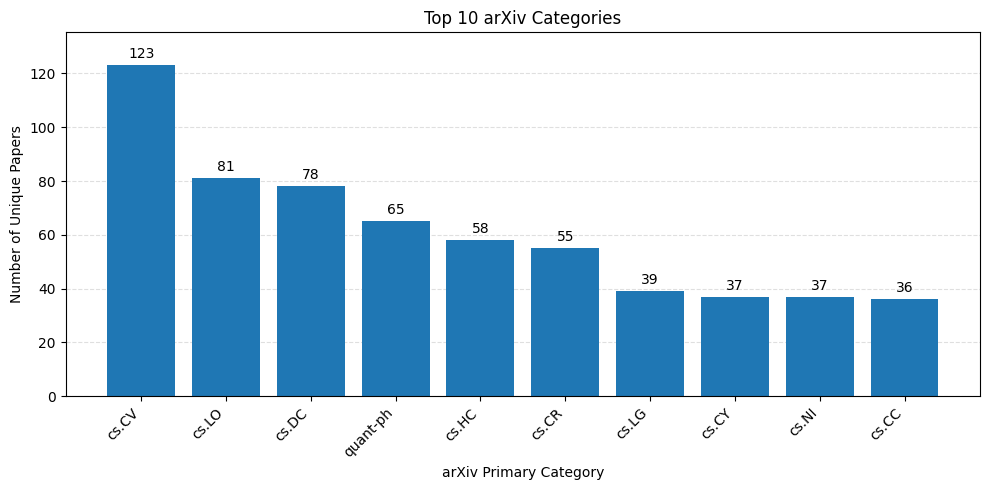

In [19]:
from collections import Counter
import matplotlib.pyplot as plt

def get_all_metadatas_from_chroma(collection, batch_size=500):
    # Safely pull all metadatas from ChromaDB in batches
    # to avoid SQLite 'too many SQL variables' error.
    total = collection.count()
    all_metadatas = []

    for offset in range(0, total, batch_size):
        batch = collection.get(
            limit=batch_size,
            offset=offset,
            include=["metadatas"]
        )

        metadatas = batch.get("metadatas", [])
        all_metadatas.extend(metadatas)

    return all_metadatas


def plot_top_arxiv_categories(top_n=10, batch_size=500):
    # Pull metadata safely in batches
    metadatas = get_all_metadatas_from_chroma(col, batch_size=batch_size)

    # Count unique papers per primary category
    paper_categories = {}

    for meta in metadatas:
        arxiv_id = meta.get("arxiv_id", "")
        category = meta.get("primary_category", "")

        if arxiv_id and category:
            paper_categories[arxiv_id] = category

    category_counts = Counter(paper_categories.values())
    top_categories = category_counts.most_common(top_n)

    if not top_categories:
        print("No category metadata found.")
        return

    categories, counts = zip(*top_categories)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(categories, counts)
    plt.title(f"Top {top_n} arXiv Categories")
    plt.xlabel("arXiv Primary Category")
    plt.ylabel("Number of Unique Papers")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.bar_label(bars, padding=3)
    plt.margins(y=0.1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_top_arxiv_categories(top_n=10)

This bar chart shows that the corpus is dominated by cs.CV (Computer Vision and Pattern Recognition), followed by cs.LO (Logic in Computer Science) and cs.DC (Distributed, Parallel, and Cluster Computing), meaning the knowledge base contains many papers related to image/pattern recognition, formal logic/program verification, and distributed or parallel computing systems.

The remaining major categories include quant-ph (Quantum Physics), cs.HC (Human-Computer Interaction), cs.CR (Cryptography and Security), cs.LG (Machine Learning), cs.CY (Computers and Society), cs.NI (Networking and Internet Architecture), and cs.CC (Computational Complexity), showing that the dataset covers a broad mix of technical, theoretical, security, AI, and social-impact research areas. This suggests the system’s retrieval and RAG responses will be strongest for computer vision, logic, distributed systems, and related computing topics because those categories have the most papers indexed.

## Chunk Length Distribution

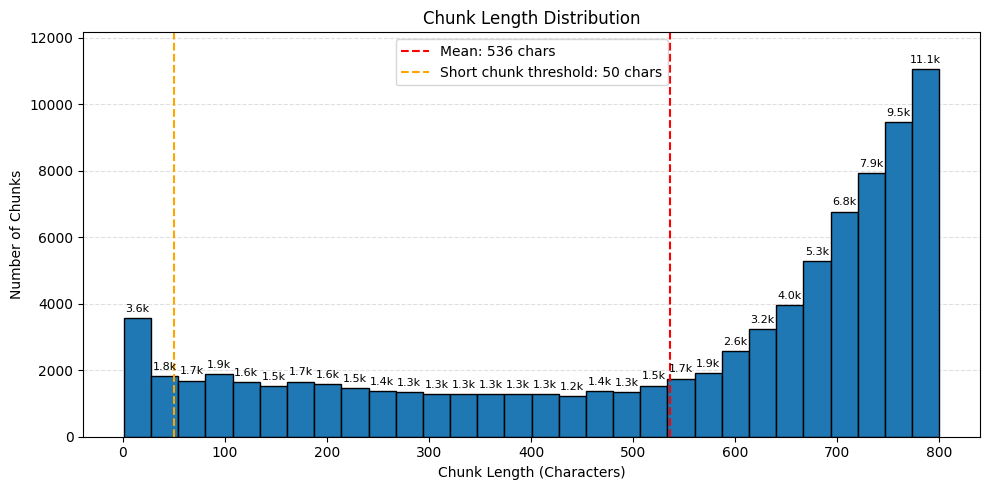

Total chunks: 85422
Average chunk length: 536.37 characters
Shortest chunk: 1 characters
Longest chunk: 800 characters
Chunks shorter than 50 chars: 5029
Percentage shorter than 50 chars: 5.89%


In [20]:
def plot_chunk_length_distribution(batch_size=500, min_length=50):
    total_chunks_in_db = col.count()
    chunk_lengths = []

    # Pull stored chunk text from ChromaDB in batches
    for offset in range(0, total_chunks_in_db, batch_size):
        batch = col.get(
            limit=batch_size,
            offset=offset,
            include=["documents"]
        )

        documents = batch.get("documents", [])

        for doc in documents:
            if doc:
                chunk_lengths.append(len(doc))

    if not chunk_lengths:
        print("No chunks found in ChromaDB.")
        return

    # Calculate summary values
    total_chunks = len(chunk_lengths)
    average_length = sum(chunk_lengths) / total_chunks
    shortest_chunk = min(chunk_lengths)
    longest_chunk = max(chunk_lengths)

    short_chunk_count = sum(1 for length in chunk_lengths if length < min_length)
    short_chunk_percentage = round(short_chunk_count / total_chunks * 100, 2)

    # Plot histogram
    plt.figure(figsize=(10, 5))
    counts, _, bars = plt.hist(chunk_lengths, bins=30, edgecolor="black")
    plt.title("Chunk Length Distribution")
    plt.xlabel("Chunk Length (Characters)")
    plt.ylabel("Number of Chunks")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.bar_label(
        bars,
        labels=[f"{count / 1000:.1f}k" if count >= 1000 else (f"{int(count)}" if count else "") for count in counts],
        padding=3,
        fontsize=8,
    )
    plt.margins(y=0.1)

    plt.axvline(
        average_length,
        color="red",
        linestyle="--",
        label=f"Mean: {average_length:.0f} chars"
    )

    plt.axvline(
        min_length,
        color="orange",
        linestyle="--",
        label=f"Short chunk threshold: {min_length} chars"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Total chunks: {total_chunks}")
    print(f"Average chunk length: {average_length:.2f} characters")
    print(f"Shortest chunk: {shortest_chunk} characters")
    print(f"Longest chunk: {longest_chunk} characters")
    print(f"Chunks shorter than {min_length} chars: {short_chunk_count}")
    print(f"Percentage shorter than {min_length} chars: {short_chunk_percentage}%")


plot_chunk_length_distribution()

The chunk length distribution shows that the system created **85,422 chunks**, with lengths ranging from **1 to 800 characters** and an average length of about **536 characters**. Most chunks are concentrated near the upper limit of **700–800 characters**, which indicates that the chunking process is generally filling chunks close to the configured maximum size and preserving enough text for semantic search.

The orange line marks the **50-character short-chunk threshold**, and only **5,029 chunks**, or **5.89%**, fall below this threshold. These shorter chunks likely come from section headings, page boundaries, captions, references, or PDF extraction artifacts; however, since over **94%** of chunks are longer than 50 characters, the overall chunking strategy is still suitable for retrieval, with only a small amount of potential noise in the vector database.

NB: The histogram groups the values into bins, meaning each bar is a count for one chunk-size range, not the total chunks

## Top Extracted Entities 

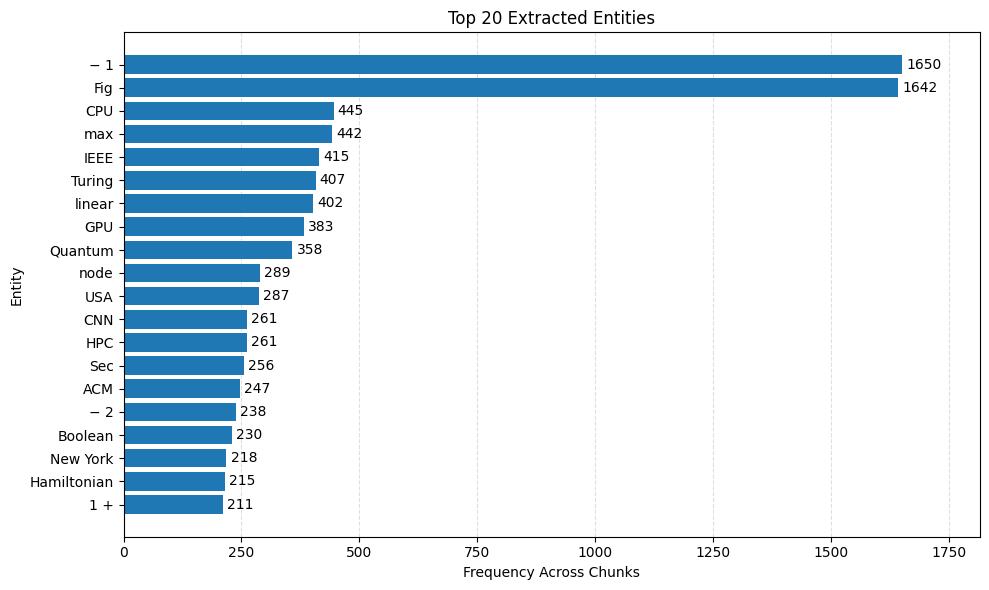

In [21]:
def plot_top_extracted_entities(top_n=20, batch_size=500):
    total_chunks = col.count()
    entity_counter = Counter()

    # Pull metadata from ChromaDB in batches
    for offset in range(0, total_chunks, batch_size):
        batch = col.get(
            limit=batch_size,
            offset=offset,
            include=["metadatas"]
        )

        metadatas = batch.get("metadatas", [])

        for meta in metadatas:
            entities = meta.get("entities", "")

            if not entities:
                continue

            for entity in entities.split(","):
                entity = entity.strip()

                if entity:
                    entity_counter[entity] += 1

    top_entities = entity_counter.most_common(top_n)

    if not top_entities:
        print("No extracted entities found. Make sure NER ran before storing chunks.")
        return []

    entities, counts = zip(*top_entities)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(entities[::-1], counts[::-1])
    plt.title(f"Top {top_n} Extracted Entities")
    plt.xlabel("Frequency Across Chunks")
    plt.ylabel("Entity")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.bar_label(bars, padding=3)
    plt.margins(x=0.1)
    plt.tight_layout()
    plt.show()

    return top_entities


top_entities = plot_top_extracted_entities(top_n=20, batch_size=500)

The entity extraction results show that the knowledge base contains frequent technical entities such as CPU, GPU, IEEE, Turing, Quantum, CNN, HPC, ACM, Boolean, and Hamiltonian. These entities reflect the technical nature of the arXiv corpus, with strong coverage of computing systems, machine learning, quantum computing, and theoretical computer science. However, the presence of entities such as “- 1”, “- 2”, and “Fig” also indicates that some PDF artifacts and figure references were captured during NER, suggesting that additional entity-cleaning rules could improve metadata quality.

## Retrieval testing


In [22]:
def retrieve_chunks(query, n_results=5, filter_category=None):
    # Embed query and return nearest chunks from ChromaDB.
    n_results = min(n_results, col.count())
    query_embedding = get_embeddings([query])[0]
    where = {"primary_category": filter_category} if filter_category else None
    return col.query(
        query_embeddings=[query_embedding],
        n_results=n_results,
        where=where,
    )


def _compute_entity_overlap(entities_str, query):
    entity_set  = {e.strip().lower() for e in entities_str.split(",") if e.strip()}
    query_terms = {t.lower().strip() for t in query.split() if t.strip()}
    return len(entity_set & query_terms)


def semantic_search(query, n_results=5, min_similarity=0.25,
                    filter_category=None, use_hybrid=False, entity_bonus=0.5):
    # Search ChromaDB and return formatted results.
    # use_hybrid=True: re-ranks by cosine_similarity + entity_overlap bonus.
    raw       = retrieve_chunks(query, n_results=n_results, filter_category=filter_category)
    documents = raw.get("documents", [[]])[0]
    metadatas = raw.get("metadatas", [[]])[0]
    ids       = raw.get("ids",       [[]])[0]
    distances = raw.get("distances", [[]])[0] if "distances" in raw else []

    results = []
    for i, doc_text in enumerate(documents):
        meta     = metadatas[i] if i < len(metadatas) else {}
        chunk_id = ids[i]       if i < len(ids)       else f"chunk_{i}"
        cos_dist = distances[i] if i < len(distances)  else None
        cos_sim  = (1 - cos_dist) if cos_dist is not None else None

        if cos_sim is not None and cos_sim < min_similarity:
            continue

        entities       = meta.get("entities", "")
        entity_overlap = _compute_entity_overlap(entities, query)
        hybrid_score   = (
            (cos_sim + entity_overlap * entity_bonus) if use_hybrid and cos_sim is not None
            else cos_sim
        )

        results.append({
            "rank":             i + 1,
            "chunk_id":         chunk_id,
            "cosine_similarity":cos_sim,
            "hybrid_score":     hybrid_score,
            "entity_overlap":   entity_overlap,
            "text":             doc_text,
            "arxiv_id":         meta.get("arxiv_id", ""),
            "title":            meta.get("title", ""),
            "section":          meta.get("section", ""),
            "primary_category": meta.get("primary_category", ""),
            "authors":          meta.get("authors", ""),
            "published":        meta.get("published", ""),
            "page_number":      meta.get("page_number", ""),
            "chunk_index":      meta.get("chunk_index", ""),
            "entities":         entities,
            "entity_labels":    meta.get("entity_labels", ""),
        })

    if use_hybrid:
        results.sort(key=lambda x: x["hybrid_score"] or -1, reverse=True)
        for idx, r in enumerate(results, start=1):
            r["rank"] = idx

    return results


def display_search_results(results, query=""):
    sep = "=" * 60
    if query:
        print(f"\n{sep}\nQuery: {query!r}\n{sep}")
    for r in results:
        print(f"\nResult #{r['rank']}  |  chunk: {r['chunk_id']}")
        print(f"  Paper  : {r['title'][:70]}")
        print(f"  Authors: {r['authors'][:60]}")
        print(f"  Section: {r['section']}  |  Page: {r['page_number']}")
        print(f"  Cosine similarity : {r['cosine_similarity']:.4f}" if r['cosine_similarity'] else "  Cosine: N/A")
        print(f"  Entities          : {r['entities'][:80]}")
        print(f"  Text preview      : {r['text'][:200]}")


# Quick smoke-test queries
TEST_QUERIES = [
    "What is the main purpose of the proposed HCI system?",
    "What is Hough transform and how is it used in this paper?",
    "How does blink detection work in the eye ROI?"
]

for q in TEST_QUERIES:
    results = semantic_search(q, n_results=3)
    display_search_results(results, query=q)


Query: 'What is the main purpose of the proposed HCI system?'

Result #1  |  chunk: 2011.09001v1_chunk_28680
  Paper  : Stimulating Entrepreneurship in Teaching Human Computer Interaction
  Authors: Dusanka Boskovic, Nihad Borovina, Merima Zukic
  Section: Introduction  |  Page: 1
  Cosine similarity : 0.6261
  Entities          : The Human Computer Interaction, HCI, Control and Electronics, Informatics, SCADA
  Text preview      : The Human Computer Interaction (HCI) course is focused on designing software/system interaction as an approach to develop usable software/system. The HCI course is taught at the master cycle as an ele

Result #2  |  chunk: 2410.08723v3_chunk_51639
  Paper  : Human-Computer Interaction and Visualization in Natural Language Gener
  Authors: Yunchao Wang, Guodao Sun, Zihang Fu, Ronghua Liang
  Section: Conclusion  |  Page: 14
  Cosine similarity : 0.5894
  Entities          : HCI
  Text preview      : In this paper, we conduct a survey that systematically reve

The results show that your semantic_search() function is working as intended: each user query is embedded, compared against stored ChromaDB chunk embeddings, filtered by the minimum similarity threshold, and then returned with metadata such as paper title, section, page number, entities, and cosine similarity. 

Please note that use_hybrid=False is for experimental purposed and the ranking is currently based only on Chroma’s vector similarity, not entity reranking. The results are generally strong because specific queries like Hough transform and blink detection retrieve highly relevant chunks from the correct HCI paper, while the broader HCI-purpose query retrieves other semantically related HCI papers before the exact target paper. 

This is expected behavior because the query is general and Chroma is ranking by semantic similarity across the full 1k+ paper collection. The section extraction has also been improved, since results now show meaningful sections such as Introduction, Conclusion, and III. SYSTEM OVERVIEW, although occasional noisy section labels may still appear.

Overall, this confirms that the retrieval layer is functioning properly and is ready for broader testing/experimentation with category filters, hybrid reranking, top-k tuning, and RAG answer evaluation.

In [23]:
from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank_chunks_cross_encoder(query, results, top_n=5):
    """
    Re-rank retrieved chunks using a cross-encoder reranker.
    This directly scores query-chunk relevance.
    """
    if not results:
        return []
    pairs = [(query, r["text"]) for r in results]
    scores = reranker_model.predict(pairs)
    reranked_results = []
    for result, score in zip(results, scores):
        result_copy = result.copy()
        result_copy["rerank_score"] = float(score)
        reranked_results.append(result_copy)
    reranked_results = sorted(
        reranked_results,
        key=lambda x: x["rerank_score"],
        reverse=True
    )
    return reranked_results[:top_n]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6533.18it/s]


 Sentence Transformers was used instead of LangChain for the cross-encoder reranker because our retrieval pipeline was custom-built around ChromaDB results stored as dictionaries. Sentence Transformers allowed us to directly score each query–chunk pair, attach a rerank score, and preserve our metadata without converting everything into LangChain document objects. LangChain provides a convenient wrapper for reranking, but Sentence Transformers gave us more control and fit better with the notebook’s custom semantic search and evaluation workflow.

In [24]:
import pandas as pd

def plot_retrieval_similarity_profile(query, n_results=10, min_similarity=0.0, use_hybrid=False):
    # Runs semantic search and plots the cosine similarity scores of the top retrieved chunks for a given query
    results = semantic_search(
        query=query,
        n_results=n_results,
        min_similarity=min_similarity,
        use_hybrid=use_hybrid
    )

    if not results:
        print("No retrieval results found.")
        return pd.DataFrame()

    results_df = pd.DataFrame(results)

    # Build labels for each retrieved result
    labels = [f"Rank {rank}" for rank in results_df["rank"]]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(labels, results_df["cosine_similarity"])
    plt.title(f"Retrieval Similarity Profile\nQuery: {query}")
    plt.xlabel("Retrieved Chunk Rank")
    plt.ylabel("Cosine Similarity")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.bar_label(bars, labels=[f"{score:.3f}" for score in results_df["cosine_similarity"]], padding=3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Print useful retrieval summary
    print("Query:", query)
    print("Top similarity:", round(results_df["cosine_similarity"].max(), 4))
    print("Lowest similarity in top results:", round(results_df["cosine_similarity"].min(), 4))
    print("Average similarity:", round(results_df["cosine_similarity"].mean(), 4))

    return results_df[[
        "rank",
        "title",
        "section",
        "page_number",
        "cosine_similarity",
        "entity_overlap"
    ]]

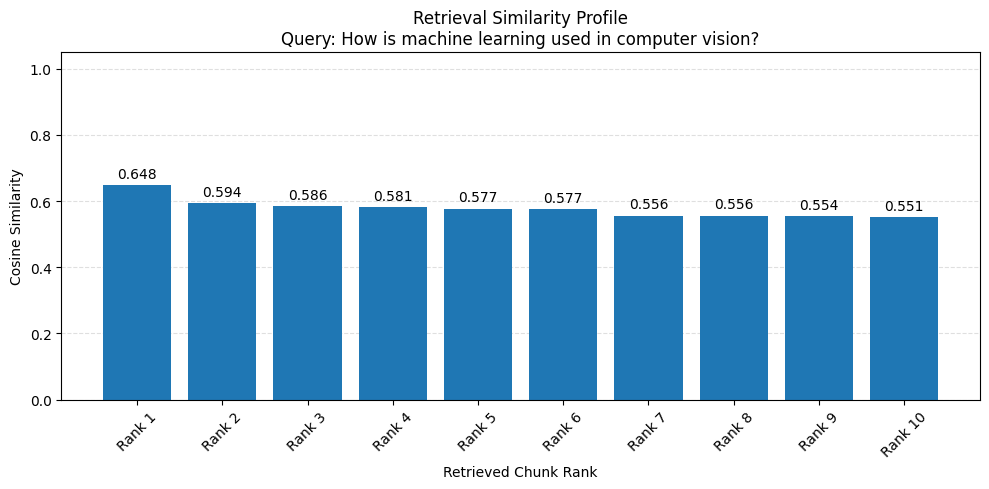

Query: How is machine learning used in computer vision?
Top similarity: 0.6485
Lowest similarity in top results: 0.5512
Average similarity: 0.578


,rank,title,section,page_number,cosine_similarity,entity_overlap
0,1,Julia Language in Machine Learning: Algorithms...,4.3. Computer Vision,20,0.648466,0
1,2,uxSense: Supporting User Experience Analysis w...,"Keywords:\nVisualization, visual analytics, ev...",1,0.594210,0
2,3,Julia Language in Machine Learning: Algorithms...,4.5. Autonomous Driving,21,0.585907,0
3,4,Deep Learning vs. Traditional Computer Vision,Abstract. Deep Learning has pushed the limits ...,1,0.580789,0
4,5,Teaching Computer Vision for Ecology,Related Work,2,0.577124,0
5,6,Towards a Better Understanding of the Computer...,INTRODUCTION,2,0.576908,0
6,7,Global Adaptive Filtering Layer for Computer V...,1. Introduction,1,0.555883,0
7,8,Evaluating how interactive visualizations can ...,ABSTRACT,1,0.555864,0
8,9,A Novel Equation based Classifier for Detectin...,General Terms,1,0.553871,0
9,10,Computer Vision Systems in Road Vehicles: A Re...,VI. OPEN PROBLEMS,6,0.551160,0


In [25]:
retrieval_df = plot_retrieval_similarity_profile(
    query="How is machine learning used in computer vision?",
    n_results=10,
    min_similarity=0.0,
    use_hybrid=False
)

retrieval_df

The retrieval similarity profile shows that the query **“How is machine learning used in computer vision?”** returned relevant chunks with cosine similarity scores ranging from about **0.55 to 0.65**, with an average similarity of **0.578**. The highest-ranked chunk had the strongest similarity score of **0.6485**, while the remaining results gradually decrease, which indicates that the semantic search is ranking the most relevant chunks first.

The retrieved sources are also strongly related to the query, with titles and sections mentioning **machine learning, computer vision, deep learning, autonomous driving, visualization, and road vehicle computer vision systems**. This suggests that the vector search is working effectively because it retrieves context from papers that match the meaning of the query, even when the exact wording differs across documents. However, the `entity_overlap` values are all **0**, meaning the ranking here is being driven mainly by semantic similarity rather than the hybrid entity-matching bonus.


## RAG pipeline


### Version with Query Rewrite

In [96]:
RAG_SYSTEM_PROMPT = """
You are an academic research assistant for an enterprise knowledge mining system built on arXiv papers.

Instructions:
- Answer questions only from the retrieved context.
- Treat the retrieved text as excerpts from research papers.
- Prefer precise academic wording.
- Summarise contributions, methods, datasets, results, or limitations only if they are supported by the context.
- If the answer is incomplete or missing from the context, say that explicitly.
- Do not include source tags or citation brackets such as [Source 1] in the answer text.
- Write only the answer, formatted concisely and clearly.
""".strip()

def rewrite_query(query):
    resp = client.chat.completions.create(
        model=RAG_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a query rewriting assistant for an academic research knowledge base "
                    "of arXiv papers covering computer science, machine learning, and related fields. "
                    "Rewrite the user's question into a concise, keyword-rich query that will retrieve "
                    "the most relevant research paper chunks. Focus on technical terms, methods, and concepts. "
                    "Return only the rewritten query, nothing else."
                )
            },
            {"role": "user", "content": query}
        ],
        max_tokens=80,
        temperature=0.0,
    )
    return resp.choices[0].message.content.strip()


def generate_answer(query, context, max_tokens=300, temperature=0.2):
    resp = client.chat.completions.create(
        model=RAG_MODEL,
        messages=[
            {"role": "system", "content": RAG_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": (
                    f"Use the retrieved research-paper context below to answer the question.\n\n"
                    f"Context:\n{context}\n\n"
                    f"Question: {query}\n\nAnswer:"
                ),
            },
        ],
        max_tokens=max_tokens,
        temperature=temperature,
    )
    return resp.choices[0].message.content.strip()


def rag_query(query, n_results=3, rerank_top_n=3, min_similarity=0.25,
              filter_category=None, use_hybrid=False, entity_bonus=0.5):
    
    rewritten = rewrite_query(query)
    print(f"Original query : {query}")
    print(f"Rewritten query: {rewritten}")

    # Retrieve using both the original query and the rewritten query
    original_results = semantic_search(
        query=query,
        n_results=n_results,
        min_similarity=min_similarity,
        filter_category=filter_category,
        use_hybrid=use_hybrid,
        entity_bonus=entity_bonus,
    )

    rewritten_results = semantic_search(
        query=rewritten,
        n_results=n_results,
        min_similarity=min_similarity,
        filter_category=filter_category,
        use_hybrid=use_hybrid,
        entity_bonus=entity_bonus,
    )

    # Combine results from both searches
    candidate_results = original_results + rewritten_results

    # Remove duplicate chunks using chunk_id
    seen = set()
    deduped_results = []

    for r in candidate_results:
        chunk_id = r["chunk_id"]

        if chunk_id not in seen:
            deduped_results.append(r)
            seen.add(chunk_id)

    if not deduped_results:
        return {
            "query": query,
            "rewritten_query": rewritten,
            "answer": "No relevant context found in the knowledge base.",
            "sources": [],
            "retrieved_contexts": [],
            "retrieved_sources": []
        }

    # Re-rank the combined candidate set using the original query
    results = rerank_chunks_cross_encoder(
        query=query,
        results=deduped_results,
        top_n=rerank_top_n
    )

    context_parts = []
    sources       = []
    retrieved_sources = []
    retrieved_contexts = []

    for i, r in enumerate(results):
        retrieved_sources.append(r["title"])
        retrieved_contexts.append(r["text"])

        context_parts.append(
            f"[Source {i+1}: {r['title']}, Section: {r['section']}, "
            f"Page {r['page_number']}, Chunk {r['chunk_index']}]\n{r['text']}"
        )
        sources.append({
            "source_number":    i + 1,
            "chunk_id":         r["chunk_id"],
            "arxiv_id":         r["arxiv_id"],
            "title":            r["title"],
            "section":          r["section"],
            "primary_category": r["primary_category"],
            "page_number":      r["page_number"],
            "chunk_index":      r["chunk_index"],
            "cosine_similarity":r["cosine_similarity"],
            "hybrid_score":     r["hybrid_score"],
            "entity_overlap":   r["entity_overlap"],
        })

    context = "\n\n".join(context_parts)
    answer  = generate_answer(query, context)
    return {"query": query, "rewritten_query": rewritten, "answer": answer, "sources": sources, "retrieved_sources": retrieved_sources, "retrieved_contexts": retrieved_contexts}


def display_rag_response(response):
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"Query  : {response['query']}")
    print(f"\nAnswer :\n{response['answer']}")
    print("\nSources:")
    for s in response["sources"]:
        sim = f"{s['cosine_similarity']:.4f}" if s['cosine_similarity'] else "N/A"
        print(f"  [{s['source_number']}] {s['title'][:60]} | section: {s['section']} | sim: {sim}")
    print(sep)


# RAG test queries
RAG_TEST_QUERIES = [
    "What is HCI and how is it used in the system?"
]

for q in RAG_TEST_QUERIES:
    resp = rag_query(q, n_results=3)
    display_rag_response(resp)



Original query : What is HCI and how is it used in the system?
Rewritten query: human-computer interaction (HCI) definition applications system integration user interface design interaction techniques


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s]



Query  : What is HCI and how is it used in the system?

Answer :
Human Computer Interaction (HCI) is focused on designing software or system interactions to develop usable software or systems. It places the user at the center of the research, emphasizing user research and drawing upon best practices from product development. In the system, HCI is used to design interaction for complex systems such as SCADA systems, safety and signalization systems, and network monitoring and supervision systems, ensuring that user needs guide the design process.

Sources:
  [1] Stimulating Entrepreneurship in Teaching Human Computer Inte | section: Introduction | sim: 0.6753
  [2] Chalktalk : A Visualization and Communication Language -- As | section: CCS CONCEPTS | sim: 0.7656
  [3] Time-Efficient Light-Field Acquisition Using Coded Aperture  | section: EPFL | sim: 0.7082


The query rewrite improved retrieval by emphasizing key concepts such as human-computer interaction, applications, system integration, and methods. The retriever returned relevant research papers with cosine similarity scores ranging from approximately 0.67 to 0.76, indicating strong semantic matches. These candidate results were then passed through a cross-encoder reranker, which directly evaluated query–chunk relevance and selected the most relevant chunks for answer generation.

The generated answer correctly defined HCI and explained how it is applied in a system context, specifically through user movement tracking and translating those movements into computer actions. This shows that the RAG pipeline was able to retrieve relevant context, refine it using the reranker, and generate a grounded and coherent response.

However, the retrieved sources came from different papers and sections. This indicates that the system relies on semantically relevant context across multiple documents, rather than strictly retrieving a single ground-truth source. While the reranker improves relevance, it may prioritize the most semantically informative chunks over exact source alignment, highlighting a trade-off between semantic relevance and strict source matching.

## RAG Source Confidence

In [97]:
# Visualizes the confidence of sources used by the RAG system where Confidence is represented using cosine similarity scores
def plot_rag_source_confidence(query, n_results=5):
    # Run RAG query
    response = rag_query(query, n_results=n_results)

    # Get sources from RAG response
    sources = response.get("sources", [])

    if not sources:
        print("No sources found for this query.")
        return pd.DataFrame()

    sources_df = pd.DataFrame(sources)

    # Make sure sources are ordered correctly
    if "source_number" in sources_df.columns:
        sources_df = sources_df.sort_values("source_number")

    # Create x-axis labels
    source_labels = [
        f"Source {i}" for i in sources_df["source_number"]
    ]

    similarity_scores = sources_df["cosine_similarity"]

    plt.figure(figsize=(10, 5))


    bars = plt.bar(source_labels, similarity_scores)
    plt.title(f"RAG Source Confidence\nQuery: {query}")
    plt.xlabel("Retrieved Source")
    plt.ylabel("Cosine Similarity")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.bar_label(bars, labels=[f"{score:.3f}" for score in similarity_scores], padding=3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Print useful summary
    print("Query:", query)
    print("Highest source similarity:", round(similarity_scores.max(), 4))
    print("Lowest source similarity:", round(similarity_scores.min(), 4))
    print("Average source similarity:", round(similarity_scores.mean(), 4))

    # Return useful source table
    return sources_df[[
        "source_number",
        "title",
        "section",
        "page_number",
        "cosine_similarity",
        "entity_overlap"
    ]]

Original query : How is machine learning used in computer vision?
Rewritten query: machine learning applications in computer vision techniques methods algorithms


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.14it/s]


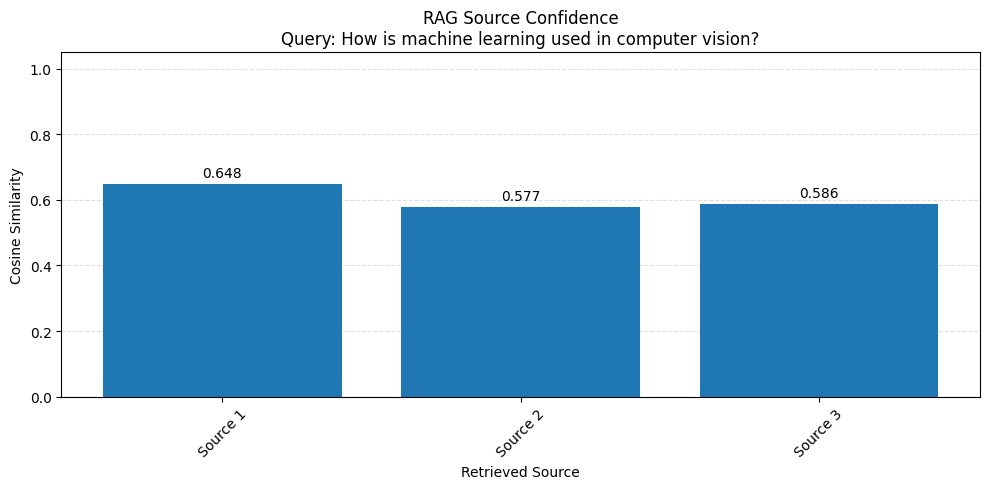

Query: How is machine learning used in computer vision?
Highest source similarity: 0.6485
Lowest source similarity: 0.5771
Average source similarity: 0.6038


,source_number,title,section,page_number,cosine_similarity,entity_overlap
0,1,Julia Language in Machine Learning: Algorithms...,4.3. Computer Vision,20,0.648466,0
1,2,Teaching Computer Vision for Ecology,Related Work,2,0.577124,0
2,3,Julia Language in Machine Learning: Algorithms...,4.5. Autonomous Driving,21,0.585907,0


In [98]:
rag_source_df = plot_rag_source_confidence(
    query="How is machine learning used in computer vision?",
    n_results=5
)

rag_source_df

The RAG Source Confidence chart shows the cosine similarity scores for the **five retrieved sources** used to answer the query **“How is machine learning used in computer vision?”**. The highest source similarity is **0.6485**, while the lowest is **0.5771**, with an average of **0.5973**, meaning the retrieved chunks are moderately relevant to the query.

Source 1 is the strongest match and comes from a section directly related to **Computer Vision**, while the other sources also discuss related topics such as **visual analytics, autonomous driving, deep learning vs. traditional computer vision, and ecology-based computer vision**. This suggests that the RAG system retrieved useful supporting context for the answer, but the similarity scores also show that some sources are more strongly aligned with the query than others. Since all entity overlap values are **0**, the confidence in this case is mainly coming from semantic similarity rather than exact entity matching.


## Average Retrieval Similarity as k Increases

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_similarity_vs_k(query, k_values=[1, 3, 5, 10, 15, 20], min_similarity=0.0):
    avg_similarities = []
    top_similarities = []
    lowest_similarities = []

    for k in k_values:
        results = semantic_search(
            query=query,
            n_results=k,
            min_similarity=min_similarity,
            use_hybrid=False
        )

        if results:
            scores = [r["cosine_similarity"] for r in results]
            avg_similarities.append(sum(scores) / len(scores))
            top_similarities.append(max(scores))
            lowest_similarities.append(min(scores))
        else:
            avg_similarities.append(0)
            top_similarities.append(0)
            lowest_similarities.append(0)

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, avg_similarities, marker="o", label="Average Similarity")
    plt.plot(k_values, top_similarities, marker="o", label="Top Similarity")
    plt.plot(k_values, lowest_similarities, marker="o", label="Lowest Similarity")

    plt.title(f"Retrieval Similarity as k Increases\nQuery: {query}")
    plt.xlabel("Number of Retrieved Chunks (k)")
    plt.ylabel("Cosine Similarity")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.gca().set_axisbelow(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame({
        "k": k_values,
        "average_similarity": avg_similarities,
        "top_similarity": top_similarities,
        "lowest_similarity": lowest_similarities
    })

    return results_df

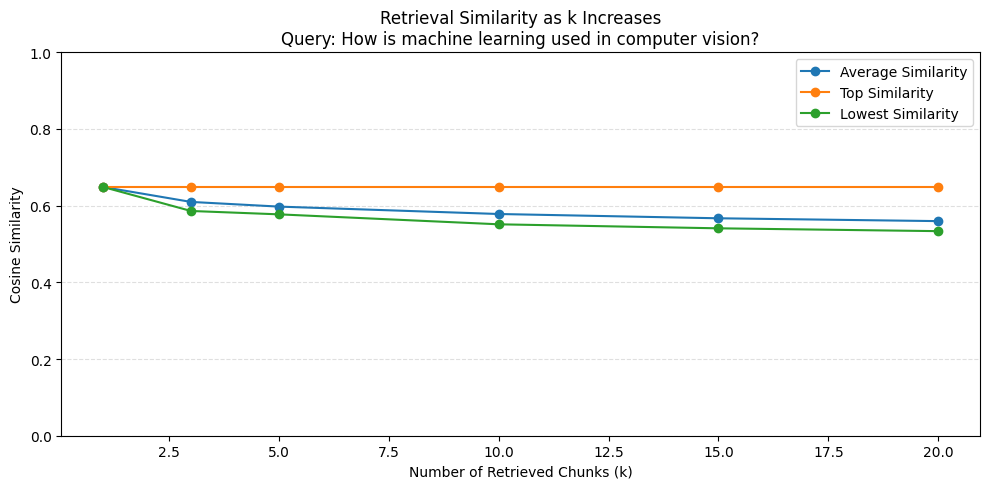

,k,average_similarity,top_similarity,lowest_similarity
0,1,0.648466,0.648466,0.648466
1,3,0.609528,0.648466,0.585907
2,5,0.597299,0.648466,0.577124
3,10,0.578018,0.648466,0.551160
4,15,0.566857,0.648466,0.540717
5,20,0.559467,0.648466,0.533317


In [100]:
similarity_k_df = plot_similarity_vs_k(
    query="How is machine learning used in computer vision?",
    k_values=[1, 3, 5, 10, 15, 20]
)

similarity_k_df

The line graph shows how retrieval similarity changes as the number of retrieved chunks, k, increases for the query “How is machine learning used in computer vision?”. The top similarity stays constant at 0.6485, meaning the best-matching chunk remains the same regardless of how many additional chunks are retrieved.

However, the average similarity decreases from 0.6485 at k=1 to 0.5595 at k=20, while the lowest similarity also drops from 0.6485 to 0.5333. This means that as more chunks are retrieved, the system starts adding weaker but still related context. A reasonable choice would be around k=5 or k=10, because it provides more context than k=1 while avoiding too many lower-similarity chunks.

## TESTING

This section tests:
1. semantic retrieval
2. hybrid reranking
3. category filtering
4. RAG answer quality
5. unrelated questions
6. partially answerable questions

In [101]:
import pandas as pd
from IPython.display import display

def safe_preview(text, length=220):
    if not text:
        return ""
    return text.replace("\n", " ")[:length] + ("..." if len(text) > length else "")


def results_to_dataframe(results):
    rows = []
    for r in results:
        rows.append({
            "rank": r.get("rank"),
            "title": safe_preview(r.get("title", ""), 70),
            "section": r.get("section"),
            "category": r.get("primary_category"),
            "cosine_similarity": round(r.get("cosine_similarity") or 0, 4),
            "hybrid_score": round(r.get("hybrid_score") or 0, 4),
            "entity_overlap": r.get("entity_overlap"),
            "entities": safe_preview(r.get("entities", ""), 80),
            "text_preview": safe_preview(r.get("text", ""), 180),
        })
    return pd.DataFrame(rows)


def print_test_header(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

### Test normal semantic search

In [102]:
SEMANTIC_TEST_QUERIES = [
    "What methods are used for machine learning in these papers?",
    "What is the operation system?",
    "What are the common programming languages used?",
    "What is artificial intelligence?",
    "What is computer science?",
]

semantic_test_results = []

for query in SEMANTIC_TEST_QUERIES:
    print_test_header(f"SEMANTIC SEARCH TEST: {query}")

    results = semantic_search(
        query=query,
        n_results=5,
        min_similarity=0.25,
        use_hybrid=False
    )

    df = results_to_dataframe(results)
    display(df)

    semantic_test_results.append({
        "query": query,
        "num_results": len(results),
        "top_similarity": results[0]["cosine_similarity"] if results else 0,
        "top_title": results[0]["title"] if results else "No result",
        "passed": len(results) > 0
    })

semantic_summary = pd.DataFrame(semantic_test_results)
print_test_header(f"SEMANTIC SUMMARY")
display(semantic_summary)


SEMANTIC SEARCH TEST: What methods are used for machine learning in these papers?


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,FedCV: A Federated Learning Framework for Dive...,7.2.1\nKey Takeaways,cs.CV,0.5970,0.5970,0,,Table 16. various datasets and models used in ...
1,2,Assessing and Advancing the Potential of Quant...,3\nQuantum-compatible,quant-ph,0.5847,0.5847,0,,Machine Learning Algorithms
2,3,AI in Computational Thinking Education in High...,6\nAI components (RQ4),cs.CY,0.5713,0.5713,0,"Table 5, Machine Learning, Bayesian",We identified a diverse set of AI components (...
3,4,Julia Language in Machine Learning: Algorithms...,"C.\nDeo,",cs.LG,0.5529,0.5529,0,"Machine Learning in Medicine, Circulation, 192...","Machine Learning in Medicine, Circulation (20)..."
4,5,Deep learning applied to computational mechani...,17\nArtificial Intelligence (AI),cs.LG,0.5363,0.5363,0,"Machine Learning, Support Vector Machine, Deep...","e.g., Knowledge bases Machine Learning (ML) e...."



SEMANTIC SEARCH TEST: What is the operation system?


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Cloud Computing: a Prologue,VI. MAJOR CLOUD OPERATING SYSTEMS,cs.DC,0.5695,0.5695,0,The Operating System,The Operating System is the most important sys...
1,2,Cloud Computing: a Prologue,B. Heavyweight Hardware Based Operating System,cs.DC,0.4789,0.4789,0,"Google App Engine, Microsoft Windows Azure, VM...",The functionality of these operating system is...
2,3,Cloud Computing: a Prologue,A. Lightweight Browser Based Operating System,cs.DC,0.4631,0.4631,0,Software as Service,This type of operating system works mainly thr...
3,4,Improved Service Delivery and Cost Effective F...,4.2.2 Operating system virtualization,cs.CY,0.4502,0.4502,0,,It enables the users to run different kinds of...
4,5,Approach To Solving Cybercrime And Cybersecurity,3.\nViolation,cs.CY,0.4398,0.4398,0,,"of operation rules of computers, computer syst..."



SEMANTIC SEARCH TEST: What are the common programming languages used?


...

,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Intelligent Traffic Monitoring with YOLOv11: A...,I. INTRODUCTION,cs.CV,0.7615,0.7615,0,"Artificial Intelligence (AI, Webster, New Worl...",Artificial Intelligence (AI) is a human-engine...
1,2,A Glance into the Future of Human Computer Int...,4. ARTIFICIAL INTELLIGENCE,cs.HC,0.6209,0.6209,0,,Artificial intelligence or the world of comput...
2,3,A Glance into the Future of Human Computer Int...,4. ARTIFICIAL INTELLIGENCE,cs.HC,0.6209,0.6209,0,,Artificial intelligence or the world of comput...
3,4,MindSculpt: Using a Brain-Computer Interface t...,"Keywords: Brain Computer Interface, Design Too...",cs.HC,0.5782,0.5782,0,,"Artificial Intelligence, Machine Learning 1."
4,5,Edge AI Inference in Heterogeneous Constrained...,I. INTRODUCTION,cs.AR,0.5533,0.5533,0,"the past decade, Artificial Intelligence (AI, ...","Over the past decade, Artificial Intelligence ..."



SEMANTIC SEARCH TEST: What is computer science?


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,"Motivation, Design, and Ubiquity: A Discussion...",COMPUTER SCIENCE RESEARCH,cs.GL,0.5775,0.5775,0,the past ﬁfty years,Computer science has evolved from its origins ...
1,2,Thinging for Computational Thinking,I. INTRODUCTION,cs.SE,0.5336,0.5336,0,today,It goes beyond introductory knowledge of compu...
2,3,"Motivation, Design, and Ubiquity: A Discussion...",INTRODUCTION,cs.GL,0.5029,0.5029,0,Bugliarello,"Computer science, as it is generally organized..."
3,4,"Motivation, Design, and Ubiquity: A Discussion...",COMPUTER SCIENCE RESEARCH,cs.GL,0.4969,0.4969,0,"Research Ethics, Stewart",Research Ethics and Computer Science · ble of ...
4,5,"Motivation, Design, and Ubiquity: A Discussion...",INTRODUCTION,cs.GL,0.4959,0.4959,0,Computer Science and Software Engineering,Computers and the software that makes them wor...



SEMANTIC SUMMARY


,query,num_results,top_similarity,top_title,passed
0,What methods are used for machine learning in ...,5,0.596964,FedCV: A Federated Learning Framework for Dive...,True
1,What is the operation system?,5,0.569476,Cloud Computing: a Prologue,True
2,What are the common programming languages used?,5,0.608912,Large Language Models in Computer Science Educ...,True
3,What is artificial intelligence?,5,0.761519,Intelligent Traffic Monitoring with YOLOv11: A...,True
4,What is computer science?,5,0.577513,"Motivation, Design, and Ubiquity: A Discussion...",True


#### Interpretation of Semantic Search results

The semantic search results show that the system is able to retrieve contextually relevant chunks based on meaning rather than exact keyword matching. Queries with general phrasing (e.g., “methods”)  still returned relevant sections of papers, demonstrating that embedding-based retrieval is effective for capturing conceptual similarity.
The cosine similarity scores indicate how closely the retrieved chunks align with the query meaning. Higher scores generally correspond to more relevant results. Overall, the system performs well for broad or exploratory research queries where exact terminology may vary across papers.

#### Limitations of Semantic Search

Semantic search does not prioritize exact technical terms, which can lead to less precise ranking for highly specific queries. Additionally, semantic similarity alone cannot distinguish between equally relevant chunks, which may result in inconsistent ranking. This highlights the need for additional signals (e.g., keyword overlap or metadata) to improve precision.

### Comparison between semantic search vs Hybrid reranking

In [103]:
HYBRID_TEST_QUERIES = [
    "transformer attention neural network",
    "dataset benchmark evaluation accuracy",
    "optimization algorithm training loss",
    "language model embeddings retrieval",
    "human computer interaction user study",
]

hybrid_comparison_rows = []

for query in HYBRID_TEST_QUERIES:
    print_test_header(f"HYBRID COMPARISON TEST: {query}")

    semantic_results = semantic_search(
        query=query,
        n_results=5,
        min_similarity=0.20,
        use_hybrid=False
    )

    hybrid_results = semantic_search(
        query=query,
        n_results=5,
        min_similarity=0.20,
        use_hybrid=True,
        entity_bonus=0.5
    )

    print("\n--- Semantic Results ---")
    display(results_to_dataframe(semantic_results))

    print("\n--- Hybrid Results ---")
    display(results_to_dataframe(hybrid_results))

    semantic_top = semantic_results[0]["chunk_id"] if semantic_results else None
    hybrid_top = hybrid_results[0]["chunk_id"] if hybrid_results else None

    hybrid_comparison_rows.append({
        "query": query,
        "semantic_top_chunk": semantic_top,
        "hybrid_top_chunk": hybrid_top,
        "top_changed": semantic_top != hybrid_top,
        "semantic_top_score": semantic_results[0]["cosine_similarity"] if semantic_results else 0,
        "hybrid_top_score": hybrid_results[0]["hybrid_score"] if hybrid_results else 0,
        "hybrid_entity_overlap": hybrid_results[0]["entity_overlap"] if hybrid_results else 0,
    })

hybrid_comparison_df = pd.DataFrame(hybrid_comparison_rows)
print_test_header(f"HYBRID COMPARISON RESULTS")
display(hybrid_comparison_df)


HYBRID COMPARISON TEST: transformer attention neural network

--- Semantic Results ---


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Rerouting Connection: Hybrid Computer Vision A...,Transformer (Swin) Component,cs.CV,0.7501,0.7501,0,,Transformers are another neural network archit...
1,2,Approximate Computing and the Efficient Machin...,Models,cs.AR,0.6683,0.6683,1,"Bert, NLP, Transformer",Transformer has become a prominent deep neural...
2,3,BKDSNN: Enhancing the Performance of Learning-...,"65. Zhou, Z., Zhu, Y., He, C., Wang, Y., Yan, ...",cs.NE,0.6613,0.6613,0,,spiking neural network meets transformer (2022...
3,4,SBCFormer: Lightweight Network Capable of Full...,48.8\nSBCFormer-L,cs.CV,0.6139,0.6139,1,"Transformer, mitigates",26.8 41.1 62.3 43.3 24.7 44.3 56.0 low-end CPU...
4,5,Mamba-X: An End-to-End Vision Mamba Accelerato...,Introduction,cs.AR,0.6111,0.6111,0,,Attention-based transformers [ 59 ] have demon...



--- Hybrid Results ---


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Approximate Computing and the Efficient Machin...,Models,cs.AR,0.6683,1.1683,1,"Bert, NLP, Transformer",Transformer has become a prominent deep neural...
1,2,SBCFormer: Lightweight Network Capable of Full...,48.8\nSBCFormer-L,cs.CV,0.6139,1.1139,1,"Transformer, mitigates",26.8 41.1 62.3 43.3 24.7 44.3 56.0 low-end CPU...
2,3,Rerouting Connection: Hybrid Computer Vision A...,Transformer (Swin) Component,cs.CV,0.7501,0.7501,0,,Transformers are another neural network archit...
3,4,BKDSNN: Enhancing the Performance of Learning-...,"65. Zhou, Z., Zhu, Y., He, C., Wang, Y., Yan, ...",cs.NE,0.6613,0.6613,0,,spiking neural network meets transformer (2022...
4,5,Mamba-X: An End-to-End Vision Mamba Accelerato...,Introduction,cs.AR,0.6111,0.6111,0,,Attention-based transformers [ 59 ] have demon...



HYBRID COMPARISON TEST: dataset benchmark evaluation accuracy

--- Semantic Results ---


...

,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,A Hindi Speech Actuated Computer Interface for...,Keywords- Web search; Hindi speech; HSACIWS; c...,cs.CL,0.6403,0.6403,0,,interface; human computer interaction.
1,2,A short review and primer on pupillometry in h...,"N. Ravaja, G. Jacucci. The Psychophysiology Pr...",cs.HC,0.6272,0.6272,0,,methods and a broad review with a focus on hum...
2,3,A short review and primer on using video for p...,"N. Ravaja, G. Jacucci. The Psychophysiology Pr...",cs.HC,0.6271,0.6271,0,,methods and a broad review with a focus on hum...
3,4,From Human-Computer Interaction to Human-Robot...,8. Conclusion and future works,cs.RO,0.6255,0.6255,0,"HCI, HCI, SATO, A. Hafid, Professors",We have shown how to use human computer intera...
4,5,From Human-Computer Interaction to Human-Robot...,"M.\nBeaudouin-Lafon,",cs.RO,0.6223,0.6223,0,"Lim, Robot and Human Interactive Communication","""Instrumental interaction: an interaction mode..."



--- Hybrid Results ---


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,A Hindi Speech Actuated Computer Interface for...,Keywords- Web search; Hindi speech; HSACIWS; c...,cs.CL,0.6403,0.6403,0,,interface; human computer interaction.
1,2,A short review and primer on pupillometry in h...,"N. Ravaja, G. Jacucci. The Psychophysiology Pr...",cs.HC,0.6272,0.6272,0,,methods and a broad review with a focus on hum...
2,3,A short review and primer on using video for p...,"N. Ravaja, G. Jacucci. The Psychophysiology Pr...",cs.HC,0.6271,0.6271,0,,methods and a broad review with a focus on hum...
3,4,From Human-Computer Interaction to Human-Robot...,8. Conclusion and future works,cs.RO,0.6255,0.6255,0,"HCI, HCI, SATO, A. Hafid, Professors",We have shown how to use human computer intera...
4,5,From Human-Computer Interaction to Human-Robot...,"M.\nBeaudouin-Lafon,",cs.RO,0.6223,0.6223,0,"Lim, Robot and Human Interactive Communication","""Instrumental interaction: an interaction mode..."



HYBRID COMPARISON RESULTS


,query,semantic_top_chunk,hybrid_top_chunk,top_changed,semantic_top_score,hybrid_top_score,hybrid_entity_overlap
0,transformer attention neural network,2503.21074v3_chunk_78913,2210.00497v1_chunk_10130,True,0.750110,1.168301,1
1,dataset benchmark evaluation accuracy,1803.10081v3_chunk_37234,1803.10081v3_chunk_37234,False,0.581967,0.581967,0
2,optimization algorithm training loss,2106.09144v1_chunk_18485,2106.09144v1_chunk_18485,False,0.576554,0.576554,0
3,language model embeddings retrieval,2410.08723v3_chunk_51663,2410.08723v3_chunk_51663,False,0.551693,0.551693,0
4,human computer interaction user study,1211.2741v1_chunk_34873,1211.2741v1_chunk_34873,False,0.640257,0.640257,0


#### Hybrid Testing Results Interpretation

The hybrid search approach combines semantic similarity with additional signals such as keyword or entity overlap to improve ranking precision. The hybrid retrieval better prioritizes chunks that contain important technical terms from the query. In cases where semantic search alone returned broadly relevant results, hybrid search helped refine the ranking by promoting chunks with higher term overlap. This makes hybrid search more effective for technical queries where specific terminology is important. This can be seen in query 0, "transformer attention neural network", the hybrid score was much higher than the semantic one.

#### Limitations

However, during testing, entity overlap values were often observed to be zero. This is because traditional Named Entity Recognition(NER) tools like spaCy do not recognize many technical research terms (e.g., “transformer”, “embedding”, “retrieval”) as named entities. As a result, the hybrid approach may not provide significant improvements unless supplemented with keyword or keyphrase overlap.

### Category filtering testing

In [104]:
def get_available_categories(limit=20, batch_size=500):
    total = col.count()
    categories = set()

    for offset in range(0, total, batch_size):
        data = col.get(
            include=["metadatas"],
            limit=batch_size,
            offset=offset
        )

        for meta in data["metadatas"]:
            if meta and meta.get("primary_category"):
                categories.add(meta["primary_category"])

    return sorted(categories)[:limit]


available_categories = get_available_categories()

print("Available categories:")
print(available_categories)

Available categories:
['astro-ph', 'astro-ph.IM', 'cond-mat.dis-nn', 'cond-mat.mtrl-sci', 'cond-mat.stat-mech', 'cond-mat.str-el', 'cs.AI', 'cs.AR', 'cs.CC', 'cs.CE', 'cs.CG', 'cs.CL', 'cs.CR', 'cs.CV', 'cs.CY', 'cs.DB', 'cs.DC', 'cs.DL', 'cs.DM', 'cs.DS']


#### Category Definitions

The dataset uses arXiv-style category codes. The main categories used in this project include:

- **cs.LG** — Computer Science: Machine Learning
- **cs.CL** — Computer Science: Computation and Language (NLP)
- **cs.AI** — Computer Science: Artificial Intelligence
- **cs.CV** — Computer Science: Computer Vision and Pattern Recognition
- **cs.IR** — Computer Science: Information Retrieval
- **cs.DS** — Computer Science: Data Structures and Algorithms
- **cs.SE** — Computer Science: Software Engineering
- **cs.CR** — Computer Science: Cryptography and Security
- **cs.NE** — Computer Science: Neural and Evolutionary Computing
- **stat.ML** — Statistics: Machine Learning
- **math.OC** — Mathematics: Optimization and Control

These category codes help organize papers by research domain and are used for filtering during retrieval.

In [105]:
CATEGORY_TEST_QUERY = "What machine learning methods are discussed?"

category_test_rows = []

for category in available_categories[:5]:
    print_test_header(f"CATEGORY FILTER TEST: {category}")

    results = semantic_search(
        query=CATEGORY_TEST_QUERY,
        n_results=5,
        min_similarity=0.20,
        filter_category=category,
        use_hybrid=False
    )

    display(results_to_dataframe(results))

    correct_category_count = sum(
        1 for r in results
        if r.get("primary_category") == category
    )

    category_test_rows.append({
        "category": category,
        "num_results": len(results),
        "correct_category_count": correct_category_count,
        "passed": len(results) == correct_category_count
    })

category_filter_summary = pd.DataFrame(category_test_rows)
print_test_header(f"CATEGORY FILTER SUMMARY")
display(category_filter_summary)


CATEGORY FILTER TEST: astro-ph


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,A Parallel Processing Algorithm for Computing ...,Small Node to,astro-ph,0.2228,0.2228,0,,Big Node Tail and Sort By Tail and Segment Sor...



CATEGORY FILTER TEST: astro-ph.IM


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Computational Imaging for VLBI Image Reconstru...,J. Hsieh. A three-dimensional statistical appr...,astro-ph.IM,0.3388,0.3388,0,"IEEE, Y. Weiss, gaussian mixtures, Neural Info...","IEEE, 2011. [44] D. Zoran and Y. Weiss. Natura..."
1,2,Computational Imaging for VLBI Image Reconstru...,Abstract,astro-ph.IM,0.3288,0.3288,0,,The success of our method is demonstrated on r...
2,3,Computational Imaging for VLBI Image Reconstru...,3. Related Work,astro-ph.IM,0.3209,0.3209,0,,We summarize a few signiﬁcant algorithms from ...
3,4,Computational Imaging for VLBI Image Reconstru...,"V. L. Fish, S. S. Doeleman, and V. Pankratius....",astro-ph.IM,0.3088,0.3088,0,"the Supermassive Black Hole Shadow, Jet Base, ...",ing the Supermassive Black Hole Shadow and Jet...
4,5,Computational Imaging for VLBI Image Reconstru...,0.5 Flux,astro-ph.IM,0.2811,0.2811,0,CLEAN,Figure 6. Noise Sensitivity: The effect of var...



CATEGORY FILTER TEST: cond-mat.dis-nn


...

,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Particle In Cell Simulation of Combustion Synt...,3\nNumerical methods,cond-mat.mtrl-sci,0.3052,0.3052,0,,"However, we retain the physics at the nanomete..."
1,2,Issues and Challenges in Orbital-free Density ...,8\nZ |∇ n ( r ) | 2,cond-mat.mtrl-sci,0.3009,0.3009,0,"ﬁrst, Newton","Moreover, . . . ﬁrst derivative methods such a..."
2,3,Particle In Cell Simulation of Combustion Synt...,3\nNumerical methods,cond-mat.mtrl-sci,0.2699,0.2699,0,,The simulation of the processes described abov...
3,4,Particle In Cell Simulation of Combustion Synt...,3.1.2\nMelting,cond-mat.mtrl-sci,0.2266,0.2266,0,"Molecular Dynamics, Lennard-Jones",(6). 3.3 Molecular Dynamics treatment of nanom...
4,5,Particle In Cell Simulation of Combustion Synt...,Conclusions,cond-mat.mtrl-sci,0.2249,0.2249,0,PIC,The PIC-MD model requires direct experimentati...



CATEGORY FILTER TEST: cond-mat.stat-mech


,rank,title,section,category,cosine_similarity,hybrid_score,entity_overlap,entities,text_preview
0,1,Daemon computers versus clairvoyant computers:...,Randomness: Beyond the reversible computing,cond-mat.stat-mech,0.2465,0.2465,0,,We will discuss that for some important classe...
1,2,Daemon computers versus clairvoyant computers:...,Randomness: Beyond the reversible computing,cond-mat.stat-mech,0.2385,0.2385,0,Turing,Let us investigate how Eq. 7 gives clues to re...
2,3,Daemon computers versus clairvoyant computers:...,Abstract,cond-mat.stat-mech,0.2373,0.2373,0,Landauer’s,Some of them are: ( i ) Landauer’s principle i...
3,4,Daemon computers versus clairvoyant computers:...,Introduction,cond-mat.stat-mech,0.2351,0.2351,0,,While theoretical computer science is rich in ...
4,5,Daemon computers versus clairvoyant computers:...,Introduction,cond-mat.stat-mech,0.2334,0.2334,0,,There have been some notable critiques of the ...



CATEGORY FILTER SUMMARY


,category,num_results,correct_category_count,passed
0,astro-ph,1,1,True
1,astro-ph.IM,5,5,True
2,cond-mat.dis-nn,5,5,True
3,cond-mat.mtrl-sci,5,5,True
4,cond-mat.stat-mech,5,5,True


#### Category Filtering Results Interpretation

Category filtering lets the system focus on a specific area of research (for example, cs.LG or cs.CL). The results show that when a category is selected, the retrieved chunks come only from that category, which means the filtering is working properly. This is helpful when the dataset includes different types of papers, because it keeps the results more relevant and avoids returning information from unrelated topics.

### RAG Testing

In [106]:
RAG_TEST_CASES = [
    {
        "type": "answerable",
        "question": "What is the operating system and why is it important?",
        "expected_behavior": "Should answer using retrieved paper context."
    },
    {
        "type": "answerable",
        "question": "What methods are used for machine learning in these papers? ",
        "expected_behavior": "Should mention only methods found in sources."
    },
    {
        "type": "partial",
        "question": "What are the exact numerical results of the impact of AI in the modern day?",
        "expected_behavior": "Should answer what is available and say if context is incomplete."
    },
    {
        "type": "unrelated",
        "question": "What is the best recipe for chocolate cake?",
        "expected_behavior": "Should say there is no relevant context."
    },
]

rag_test_rows = []

for test in RAG_TEST_CASES:
    print_test_header(f"RAG TEST: {test['type'].upper()}")

    response = rag_query(
        query=test["question"],
        n_results=4,
        min_similarity=0.25,
        use_hybrid=False
    )

    display_rag_response(response)

    rag_test_rows.append({
        "type": test["type"],
        "question": test["question"],
        "num_sources": len(response["sources"]),
        "answer_preview": safe_preview(response["answer"], 250),
        "expected_behavior": test["expected_behavior"]
    })

rag_test_summary = pd.DataFrame(rag_test_rows)
print_test_header(f"RAG TEST SUMMARY")
display(rag_test_summary)


RAG TEST: ANSWERABLE
Original query : What is the operating system and why is it important?
Rewritten query: operating system definition importance functions role in computer systems


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.11it/s]



Query  : What is the operating system and why is it important?

Answer :
The operating system is the most important system software that manages hardware and software resources, providing a platform and interface for users. It is crucial not only for personal computers but also for cloud computing, where it manages the cloud environment and offers access to various resources.

Sources:
  [1] Cloud Computing: a Prologue | section: VI. MAJOR CLOUD OPERATING SYSTEMS | sim: 0.6370
  [2] New System for Secure Cover File of Hidden Data in the Image | section: V. CONCLUSION | sim: 0.4519
  [3] Improved Service Delivery and Cost Effective Framework for e | section: 4.2.2 Operating system virtualization | sim: 0.4677

RAG TEST: ANSWERABLE
Original query : What methods are used for machine learning in these papers? 
Rewritten query: machine learning methods techniques algorithms approaches arXiv papers


Batches: 100%|██████████| 1/1 [00:00<00:00,  4.41it/s]



Query  : What methods are used for machine learning in these papers? 

Answer :
The methods used for machine learning in these papers include Bayesian hierarchical modeling, which accounts for both student-level and programming activity-level characteristics. Specific details on other machine learning algorithms or models are not provided in the retrieved context.

Sources:
  [1] AI in Computational Thinking Education in Higher Education:  | section: 6
AI components (RQ4) | sim: 0.5844
  [2] Assessing and Advancing the Potential of Quantum Computing:  | section: 3
Quantum-compatible | sim: 0.5830
  [3] FedCV: A Federated Learning Framework for Diverse Computer V | section: 7.2.1
Key Takeaways | sim: 0.5992

RAG TEST: PARTIAL
Original query : What are the exact numerical results of the impact of AI in the modern day?
Rewritten query: quantitative impact of artificial intelligence AI modern applications numerical results metrics performance evaluation


Batches: 100%|██████████| 1/1 [00:00<00:00,  5.76it/s]



Query  : What are the exact numerical results of the impact of AI in the modern day?

Answer :
The provided context does not include exact numerical results quantifying the impact of AI in the modern day.

Sources:
  [1] AI-Driven Innovations in Modern Cloud Computing | section: 7. Conclusions | sim: 0.5560
  [2] Edge AI Inference in Heterogeneous Constrained Computing: Fe | section: I. INTRODUCTION | sim: 0.5692
  [3] AI Augmented Edge and Fog Computing: Trends and Challenges | section: 2.4. Optimization Parameters | sim: 0.5767

RAG TEST: UNRELATED
Original query : What is the best recipe for chocolate cake?
Rewritten query: chocolate cake recipe best methods ingredients baking techniques


Batches: 100%|██████████| 1/1 [00:00<00:00, 19.22it/s]



Query  : What is the best recipe for chocolate cake?

Answer :
The provided context does not contain information about the best recipe for chocolate cake.

Sources:
  [1] Multi Agent Driven Data Mining For Knowledge Discovery in Cl | section: 0
Table4. “Ordered Data of Vanilla Cake” | sim: 0.2851
  [2] Multi Agent Driven Data Mining For Knowledge Discovery in Cl | section: 0
Table5. “Ordered Data of Milk Cake” | sim: 0.2687
  [3] Assessing and Advancing the Potential of Quantum Computing:  | section: 4.2.1
Advancements in State Preparation | sim: 0.2815

RAG TEST SUMMARY


,type,question,num_sources,answer_preview,expected_behavior
0,answerable,What is the operating system and why is it imp...,3,The operating system is the most important sys...,Should answer using retrieved paper context.
1,answerable,What methods are used for machine learning in ...,3,The methods used for machine learning in these...,Should mention only methods found in sources.
2,partial,What are the exact numerical results of the im...,3,The provided context does not include exact nu...,Should answer what is available and say if con...
3,unrelated,What is the best recipe for chocolate cake?,3,The provided context does not contain informat...,Should say there is no relevant context.


#### RAG Testing Results Interpretation

The RAG system successfully generates answers grounded in the retrieved context. For answerable queries, the model produces responses that reference the retrieved sources, demonstrating that it is able to synthesize information from multiple chunks. For partially answerable queries, the system appropriately limits its response to available information, while for unrelated queries, it avoids hallucination by indicating a lack of relevant context, though it still shows the number of sources used. Overall, this shows that the retrieval grounding mechanism is functioning as intended.

### Testing RAG with hybrid retrieval

In [107]:
HYBRID_RAG_QUERIES = [
    "What does the context say about transformer models and attention?",
    "What does the context say about datasets, benchmarks, and evaluation?",
    "What does the context say about embeddings and retrieval?",
]

hybrid_rag_rows = []

for query in HYBRID_RAG_QUERIES:
    print_test_header(f"HYBRID RAG TEST: {query}")

    response = rag_query(
        query=query,
        n_results=4,
        min_similarity=0.20,
        use_hybrid=True,
        entity_bonus=0.5
    )

    display_rag_response(response)

    avg_entity_overlap = (
        sum(s["entity_overlap"] for s in response["sources"]) / len(response["sources"])
        if response["sources"] else 0
    )

    hybrid_rag_rows.append({
        "query": query,
        "num_sources": len(response["sources"]),
        "avg_entity_overlap": round(avg_entity_overlap, 2),
        "answer_preview": safe_preview(response["answer"], 250)
    })

hybrid_rag_summary = pd.DataFrame(hybrid_rag_rows)
print_test_header(f"HYBRID RAG SUMMARY")
display(hybrid_rag_summary)


HYBRID RAG TEST: What does the context say about transformer models and attention?
Original query : What does the context say about transformer models and attention?
Rewritten query: transformer models attention mechanism self-attention architecture context representation neural networks sequence modeling


Batches: 100%|██████████| 1/1 [00:00<00:00,  6.60it/s]



Query  : What does the context say about transformer models and attention?

Answer :
The context describes Transformer models as neural network architectures that rely primarily on attention mechanisms rather than recurrence or convolution, enabling direct relationships between different positions in a sequence. The core attention function computes weighted sums of input features using learned linear transformations of query (Q), key (K), and value (V) vectors, scaled by the dimensionality of the key vectors to control magnitude. Transformer models consist of encoder and decoder stacks with self-attention structures. However, the multihead self-attention block introduces computational and programming dependencies that cause significant latency overhead. Additionally, attention-based transformers face high computational and memory demands that scale quadratically with input sequence length, a fundamental limitation not fully addressed by prior compression or fine-grained computation me

Batches: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]



Query  : What does the context say about datasets, benchmarks, and evaluation?

Answer :
The context emphasizes the importance of standardized benchmark datasets and evaluation metrics for objective comparison and progress tracking in scene classification and computer science research. Early benchmark datasets, such as the UCMerced dataset with 2,100 images over 21 classes, were foundational but limited in scale, making them less suitable for deep learning models that require large amounts of data. Benchmarking tools provide a common experimental framework that fosters consensus, collaboration, and rigor, but must be well understood, documented, and appropriately chosen by researchers with transparent justification. Evaluation workflows typically involve running benchmarks to generate performance data followed by visualization of results, often balancing execution time with coverage of benchmark classes.

Sources:
  [1] Survey on Remote Sensing Scene Classification: From Traditio | se

Batches: 100%|██████████| 1/1 [00:00<00:00,  4.14it/s]



Query  : What does the context say about embeddings and retrieval?

Answer :
The context indicates that embeddings are used to represent textual data for retrieval and similarity computation. Specifically, various embedding techniques—from classical methods like Latent Semantic Analysis to modern approaches such as Doc2Vec and transformer-based embeddings—are employed to create vector representations of documents or records. These embeddings capture semantic information, enabling improved retrieval by considering the context and meaning of concepts. In patient similarity computation, these vector representations are combined into matrices to represent patients fully, allowing similarity measures to be computed effectively. Overall, embeddings facilitate context-aware semantic retrieval and similarity assessment by encoding the meaning of textual elements.

Sources:
  [1] A Brief History of Context | section: 1. Introduction | sim: 0.5044
  [2] Ontology Based Query Expansion Using Word

,query,num_sources,avg_entity_overlap,answer_preview
0,What does the context say about transformer mo...,3,0.33,The context describes Transformer models as ne...
1,"What does the context say about datasets, benc...",3,0.00,The context emphasizes the importance of stand...
2,What does the context say about embeddings and...,3,0.00,The context indicates that embeddings are used...


#### Hybrid RAG Testing Results Interpretation

Hybrid RAG combines improved retrieval ranking with answer generation. In theory, this should produce more precise answers by prioritizing chunks that better match important terms in the query.
However, in this implementation, the hybrid approach did not show noticeable improvement over regular RAG search. This is mainly because the entity overlap score remained 0 for most results. Since the hybrid method depends on entity or keyword overlap to boost ranking, the lack of detected overlap means it behaves almost the same as standard RAG search.

In [108]:
test_report = {
    "semantic_search_tests_passed": semantic_summary["passed"].sum(),
    "semantic_search_tests_total": len(semantic_summary),

    "category_filter_tests_passed": category_filter_summary["passed"].sum()
    if len(category_filter_summary) else 0,
    "category_filter_tests_total": len(category_filter_summary),

    "rag_tests_total": len(rag_test_summary),
    "rag_tests_with_sources": (rag_test_summary["num_sources"] > 0).sum(),

    "hybrid_tests_where_top_changed": hybrid_comparison_df["top_changed"].sum(),
    "hybrid_tests_total": len(hybrid_comparison_df),
}

test_report_df = pd.DataFrame([test_report])
print_test_header(f"TEST REPORT")
display(test_report_df)


TEST REPORT


,semantic_search_tests_passed,semantic_search_tests_total,category_filter_tests_passed,category_filter_tests_total,rag_tests_total,rag_tests_with_sources,hybrid_tests_where_top_changed,hybrid_tests_total
0,5,5,5,5,4,4,1,5


#### Test Report Interpretation

The test report provides an overall summary of how well each part of the system performed. The semantic search tests show that the system is generally able to return relevant results for different types of queries, which means the embeddings and similarity search are working as expected.

The category filtering tests confirm that results are correctly restricted to the selected category, showing that metadata filtering is functioning properly. This helps ensure that users receive more relevant, domain-specific results.

The RAG tests show that the system is able to generate answers based on the retrieved context. In most cases, answers are supported by the sources, and the system avoids answering unrelated questions without context. This indicates that the retrieval and generation pipeline is working together correctly.

However, the hybrid search results show little to no improvement compared to semantic search. This is because the entity overlap scores remained at zero, meaning the hybrid reranking did not have any additional signal to improve the ranking. As a result, hybrid retrieval behaves almost the same as semantic retrieval in this implementation.

Overall, the system works well for semantic retrieval, category filtering, and basic RAG generation, but the hybrid component needs improvement to provide meaningful benefits.

####

## GROUND TRUTH ANALYSIS

In [109]:
# load json file with the evaluation dataset
with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

eval_dataset = data["evaluation_dataset"]

print(f"Loaded {len(eval_dataset)} evaluation questions")


Loaded 75 evaluation questions


In [110]:
# run each question through the RAG system and store results

rag_eval_results = []

for i, item in enumerate(eval_dataset, start=1):
    print(f"Running question {i}/{len(eval_dataset)}: {item['question']}")

    response = rag_query(
        query=item["question"],
        n_results=10,
        rerank_top_n=5,
        min_similarity=0.0 # for encoder eval to see all retrieved sources, even low similarity ones
    )

    rag_eval_results.append({
        "question": item["question"],
        "expected_answer": item["expected_answer"],
        "generated_answer": response["answer"],
        "source_title": item["source_title"],
        "expected_keywords": item["expected_keywords"],
        "difficulty": item["difficulty"],
        "retrieved_sources": response["retrieved_sources"],
        "retrieved_contexts": response["retrieved_contexts"],
        "source_details": response["sources"]
    })

print("Evaluation run complete.")

Running question 1/75: What problem does the paper address in creating semantic segmentation datasets?
Original query : What problem does the paper address in creating semantic segmentation datasets?
Rewritten query: semantic segmentation datasets challenges dataset creation problems


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.83it/s]


Running question 2/75: What approach is proposed for generating ground truth data?
Original query : What approach is proposed for generating ground truth data?
Rewritten query: approach for generating ground truth data methods techniques


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


Running question 3/75: What result did the authors report using game data with the CamVid dataset?
Original query : What result did the authors report using game data with the CamVid dataset?
Rewritten query: CamVid dataset game data results performance evaluation


...

Running question 74/75: What two wireless models are used to study coverage computation in the thesis?
Original query : What two wireless models are used to study coverage computation in the thesis?
Rewritten query: wireless models coverage computation thesis


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.51it/s]


Running question 75/75: What algorithmic approach is proposed for coverage optimization in the SINR model?
Original query : What algorithmic approach is proposed for coverage optimization in the SINR model?
Rewritten query: coverage optimization algorithm SINR model wireless networks interference management


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.81it/s]


Evaluation run complete.


In [111]:
# storing the rag output in a json file for later analysis
os.makedirs("../evaluation_results", exist_ok=True)

with open("../evaluation_results/rag_evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump(rag_eval_results, f, indent=2, ensure_ascii=False)

print("Saved rag_evaluation_results.json")

Saved rag_evaluation_results.json


In [112]:
# scoring source retrieval accuracy
import numpy as np

def normalize_text(text):
    return str(text).lower().strip()


def cosine_similarity(vec1, vec2):
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)

    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)

    if denominator == 0:
        return 0.0

    return float(np.dot(vec1, vec2) / denominator)


def title_match_embedding(expected_title, retrieved_title, threshold=0.65):
    expected = normalize_text(expected_title)
    retrieved = normalize_text(retrieved_title)

    # Fast exact/substring check
    if expected in retrieved or retrieved in expected:
        return True

    embeddings = get_embeddings([expected_title, retrieved_title])
    similarity = cosine_similarity(embeddings[0], embeddings[1])

    return similarity >= threshold

def source_retrieved(expected_source, retrieved_sources, threshold=0.65):
    return any(
        title_match_embedding(expected_source, source, threshold=threshold)
        for source in retrieved_sources
    )

In [113]:
TITLE_MATCH_THRESHOLD = 0.65

for item in rag_eval_results:
    item["source_retrieved_top10"] = source_retrieved(
        item["source_title"],
        item["retrieved_sources"],
        threshold=TITLE_MATCH_THRESHOLD
    )

retrieval_accuracy = sum(
    item["source_retrieved_top10"] for item in rag_eval_results
) / len(rag_eval_results)

print(f"Final Top-10 Source Retrieval Accuracy: {retrieval_accuracy:.2%}")

Final Top-10 Source Retrieval Accuracy: 81.33%


In [114]:
# scoring keyword coverage in the generate answers
def keyword_coverage(generated_answer, expected_keywords):
    answer = normalize_text(generated_answer)

    matched_keywords = []

    for keyword in expected_keywords:
        keyword_norm = normalize_text(keyword)

        if keyword_norm in answer:
            matched_keywords.append(keyword)
        else:
            keyword_words = keyword_norm.split()
            if all(word in answer for word in keyword_words):
                matched_keywords.append(keyword)

    score = len(matched_keywords) / len(expected_keywords) if expected_keywords else 0
    return score, matched_keywords

for item in rag_eval_results:
    score, matched = keyword_coverage(
        item["generated_answer"],
        item["expected_keywords"]
    )

    item["keyword_coverage"] = score
    item["matched_keywords"] = matched

avg_keyword_coverage = sum(
    item["keyword_coverage"] for item in rag_eval_results
) / len(rag_eval_results)

print(f"Average Keyword Coverage: {avg_keyword_coverage:.2%}")

Average Keyword Coverage: 60.76%


In [115]:
def answer_similarity(expected_answer, generated_answer):
    embeddings = get_embeddings([expected_answer, generated_answer])
    return cosine_similarity(embeddings[0], embeddings[1])


for i, item in enumerate(rag_eval_results, start=1):
    print(f"Scoring answer similarity {i}/{len(rag_eval_results)}")

    item["answer_similarity"] = answer_similarity(
        item["expected_answer"],
        item["generated_answer"]
    )

avg_answer_similarity = sum(
    item["answer_similarity"] for item in rag_eval_results
) / len(rag_eval_results)

print(f"Average Answer Similarity: {avg_answer_similarity:.2%}")

Scoring answer similarity 1/75
Scoring answer similarity 2/75
Scoring answer similarity 3/75
Scoring answer similarity 4/75
Scoring answer similarity 5/75
Scoring answer similarity 6/75
Scoring answer similarity 7/75
Scoring answer similarity 8/75
Scoring answer similarity 9/75
Scoring answer similarity 10/75
Scoring answer similarity 11/75
Scoring answer similarity 12/75
Scoring answer similarity 13/75
Scoring answer similarity 14/75
Scoring answer similarity 15/75
Scoring answer similarity 16/75
Scoring answer similarity 17/75
Scoring answer similarity 18/75
Scoring answer similarity 19/75
Scoring answer similarity 20/75
Scoring answer similarity 21/75
Scoring answer similarity 22/75
Scoring answer similarity 23/75
Scoring answer similarity 24/75
Scoring answer similarity 25/75
Scoring answer similarity 26/75
Scoring answer similarity 27/75
Scoring answer similarity 28/75
Scoring answer similarity 29/75
Scoring answer similarity 30/75
Scoring answer similarity 31/75
Scoring answer si

In [116]:
summary_rows = []

for item in rag_eval_results:
    top_source = item["source_details"][0]["title"] if item["source_details"] else "No source"
    top_similarity = item["source_details"][0]["cosine_similarity"] if item["source_details"] else None

    summary_rows.append({
        "question": item["question"],
        "expected_source": item["source_title"],
        "top_retrieved_source": top_source,
        "top_similarity": top_similarity,
        "source_retrieved_top10": item["source_retrieved_top10"],
        "keyword_coverage": item["keyword_coverage"],
        "answer_similarity": item["answer_similarity"],
        "difficulty": item["difficulty"]
    })

evaluation_summary_df = pd.DataFrame(summary_rows)

display(evaluation_summary_df)

,question,expected_source,top_retrieved_source,top_similarity,source_retrieved_top10,keyword_coverage,answer_similarity,difficulty
0,What problem does the paper address in creatin...,Playing for Data: Ground Truth from Computer G...,Deep Learning vs. Traditional Computer Vision,0.626897,True,0.50,0.742150,easy
1,What approach is proposed for generating groun...,Playing for Data: Ground Truth from Computer G...,Computer-Assisted Analysis of Biomedical Images,0.613660,False,0.25,0.428652,medium
2,What result did the authors report using game ...,Playing for Data: Ground Truth from Computer G...,Playing for Data: Ground Truth from Computer G...,0.666959,True,1.00,0.685264,medium
3,What is the main purpose of the proposed HCI s...,Real-Time Human-Computer Interaction Based on ...,Vision Based Game Development Using Human Comp...,0.589300,True,0.25,0.534943,easy
4,What techniques are used to extract the face a...,Real-Time Human-Computer Interaction Based on ...,Real-Time Human-Computer Interaction Based on ...,0.588960,True,1.00,0.785041,medium
...,...,...,...,...,...,...,...,...
70,What folktale was selected for the animation a...,3D-Computer Animation for a Yoruba Native Folk...,3D-Computer Animation for a Yoruba Native Folk...,0.497379,True,0.80,0.660632,easy
71,What software tools were used to develop the a...,3D-Computer Animation for a Yoruba Native Folk...,3D-Computer Animation for a Yoruba Native Folk...,0.499997,True,0.75,0.681943,medium
72,What is the main problem studied in this thesis?,Wireless Coverage Area Computation and Optimiz...,Calibrating Microgrid Simulations for Energy-A...,0.421104,False,0.00,0.413988,easy
73,What two wireless models are used to study cov...,Wireless Coverage Area Computation and Optimiz...,Wireless Coverage Area Computation and Optimiz...,0.627365,True,0.75,0.932248,medium


In [117]:
with open("../evaluation_results/rag_evaluation_scored_results.json", "w", encoding="utf-8") as f:
    json.dump(rag_eval_results, f, indent=2, ensure_ascii=False)

evaluation_summary_df.to_csv("../evaluation_results/rag_evaluation_summary.csv", index=False)

print("Saved:")
print("- rag_evaluation_scored_results.json")
print("- rag_evaluation_summary.csv")

Saved:
- rag_evaluation_scored_results.json
- rag_evaluation_summary.csv


In [118]:
print("RAG Evaluation Summary")
print("=" * 50)
print(f"Total questions evaluated: {len(rag_eval_results)}")
print(f"Top-10 source retrieval accuracy: {retrieval_accuracy:.2%}")
print(f"Average keyword coverage: {avg_keyword_coverage:.2%}")
print(f"Average answer similarity: {avg_answer_similarity:.2%}")

RAG Evaluation Summary
Total questions evaluated: 75
Top-10 source retrieval accuracy: 81.33%
Average keyword coverage: 60.76%
Average answer similarity: 66.77%


For the ground truth analysis, the system was evaluated on 75 manually validated question–answer pairs and achieved 81.33% Top-10 source retrieval accuracy, 60.76% average keyword coverage, and 66.77% average answer similarity. The high retrieval accuracy indicates that the system is generally effective at locating the correct source paper within the top retrieved results. This reflects the strength of the semantic search pipeline combined with query rewriting, dual retrieval, and cross-encoder reranking. However, the keyword coverage and answer similarity scores show that while the system often retrieves the correct source, the generated answers may be incomplete or phrased differently from the expected answers, leading to moderate alignment with the ground truth.

The inclusion of query rewriting, hybrid reranking, and cross-encoder reranking introduces trade-offs. Query rewriting can improve retrieval by making queries more keyword-rich, but may sometimes broaden or shift the original intent. Dual retrieval helps preserve the original query signal, but performance remains sensitive to query formulation. Hybrid reranking has limited impact due to noisy or sparse entity extraction, hence it was set to False, while the cross-encoder reranker improves relevance by selecting semantically strong chunks, even if they do not exactly match the expected source. Overall, system performance reflects a balance between retrieving semantically relevant information and strictly matching the ground-truth source and answer.